# 🦅 EAGLE-3 на Qwen3-1.7B: где спекулятивное декодирование ускоряет вдвое, а где замедляет

*Автор: [Georgy Mamarin](https://www.kaggle.com/georgymamarin) · разбор статьи [EAGLE-3](https://arxiv.org/abs/2503.01840): Yuhui Li, Fangyun Wei, Chao Zhang, Hongyang Zhang, NeurIPS 2025*

Языковая модель пишет по одному токену за раз, и каждый токен стоит отдельного прохода через все её веса. Спекулятивное декодирование обходит это так: маленькая черновая модель заранее предлагает несколько следующих токенов, большая целевая проверяет их разом за один проход и оставляет те, что совпали с её собственным выбором. Текст на выходе тот же — быстрее становится только его получение.

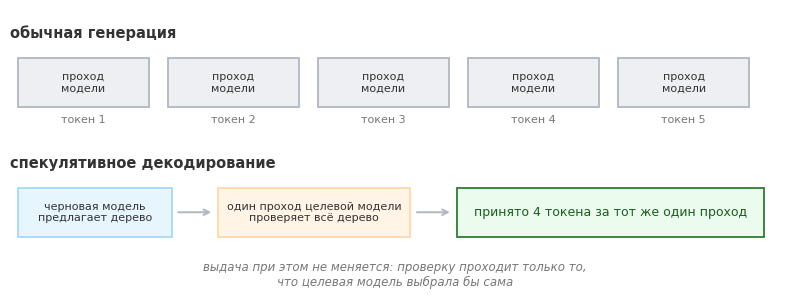

In [1]:
# --- Одна картинка, объясняющая метод ------------------------------------------
import os
import matplotlib.pyplot as plt

C_INK = "#333333"
KAGGLE_BODY_PX = 730          # ширина тела ноутбука на странице Kaggle

def finish(name):
    """Показать фигуру и сохранить её в том размере, в каком её увидит читатель."""
    os.makedirs("/kaggle/working/figs", exist_ok=True)
    plt.tight_layout()
    w_in = plt.gcf().get_size_inches()[0]
    plt.savefig(f"/kaggle/working/figs/{name}.png",
                dpi=KAGGLE_BODY_PX / w_in, bbox_inches="tight")
    plt.show()

fig, ax = plt.subplots(figsize=(8.0, 3.1))
ax.set_xlim(0, 20); ax.set_ylim(0, 6.4); ax.axis("off")

def cell(x, y, w, h, text, fc, ec, fs=8.5, tc="#333333"):
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=fc, edgecolor=ec, lw=1.3, zorder=2))
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=fs, color=tc, zorder=3)

ax.text(0, 5.7, "обычная генерация", fontsize=10.5, color=C_INK, weight="bold")
for k in range(5):
    cell(0.2 + k*3.9, 4.0, 3.4, 1.2, "проход\nмодели", "#EDEFF3", "#B0B7C3", fs=8)
    ax.text(0.2 + k*3.9 + 1.7, 3.6, f"токен {k+1}", ha="center", fontsize=8, color="#777")

ax.text(0, 2.5, "спекулятивное декодирование", fontsize=10.5, color=C_INK, weight="bold")
cell(0.2, 0.8, 4.0, 1.2, "черновая модель\nпредлагает дерево", "#E7F5FF", "#A5D8FF", fs=8)
cell(5.4, 0.8, 5.0, 1.2, "один проход целевой модели\nпроверяет всё дерево",
     "#FFF4E6", "#FFD8A8", fs=8)
cell(11.6, 0.8, 8.0, 1.2, "принято 4 токена за тот же один проход",
     "#EBFBEE", "#2E7D32", fs=9, tc="#1B5E20")
for x0, x1 in ((4.3, 5.3), (10.5, 11.5)):
    ax.annotate("", xy=(x1, 1.4), xytext=(x0, 1.4),
                arrowprops=dict(arrowstyle="->", color="#B0B7C3", lw=1.4))
ax.text(10.0, 0.2, "выдача при этом не меняется: проверку проходит только то,\n"
                   "что целевая модель выбрала бы сама",
        ha="center", va="top", fontsize=8.5, color="#777", style="italic")
finish("hero")


Сверху — обычная генерация: пять проходов ради пяти токенов. Снизу — четыре из тех же пяти токенов за один проход целевой модели; пятый достанется следующему циклу. Сколько именно выйдет выигрыша, решает одно: часто ли угадывает черновая модель.

Авторы заявляют ускорение до 6.5 раза. Я повторил их метод на Qwen3-1.7B и бесплатной Kaggle T4: на математике и коде получилось около двух с половиной раз, на русскоязычных запросах — около 0.95, то есть генерация стала медленнее обычной. Последнее, как выяснится, свойство не языка: черновая модель угадывает здесь редко, и вдобавок ей дают угадывать слишком далеко вперёд. Если сократить, насколько далеко она заглядывает, те же запросы выходят в небольшой плюс. Оба числа следуют из одного выражения для ускорения. В [§1](#s1) я его вывожу, дальше измеряю по отдельности всё, что в него входит, и показываю, что когда перевешивает.

*Run All работает без прикреплённых данных: нужны GPU T4 и включённый интернет; прогон занимает около 35 минут. English summary is at the bottom of [§14](#use-it).*

### Что сделано

- Запустил EAGLE-3 на Qwen3-1.7B кодом официального репозитория — [§4](#s4).
- Сравнил обычную авторегрессионную генерацию и EAGLE-3 на пяти наборах запросов — [§5](#s5).
- Построил, разобрал и измерил дерево черновиков — [§6](#s6)–[§8](#s8).
- Прогнал тот же протокол на цели вдвое крупнее, Qwen3-4B — [§11](#scaling).

### Что вы узнаете

1. Почему проверка целого дерева черновиков стоит столько же, сколько генерация одного токена — по замеру, а не по спецификации карты.
2. Сколько на самом деле стоит обычный шаг генерации: вчетверо больше теоретического минимума, и часть выигрыша метода — это амортизация неоптимальности базового варианта.
3. Как выглядит дерево черновиков изнутри и сколько добавляет ветвление против простой цепочки.
4. Какая форма дерева оптимальна — по одному параметру за раз и с повторами, а не «покрутили три ручки сразу».
5. Как убедиться, что метод не портит выдачу: потокенно при жадном декодировании и статистически при сэмплировании.
6. Когда метод вредит: на чужом для черновой модели домене и глубоком дереве он проигрывает обычной генерации.
7. Окупается ли метод лучше на большей цели: распространённую интуицию я довожу до замера на Qwen3-4B.

### Содержание

- [0. Параметры прогона](#s0)
- [1. Арифметика декодирования](#s1)
- [2. KV-кэш: цена памяти и почему дерево вообще возможно](#s2)
- [3. Что именно меняет EAGLE-3 — и что из этого видно в коде](#s3)
- [4. Запуск: три способа генерации на одной модели](#s4)
- [5. Бенчмарк на наборах из статьи](#s5)
- [6. Дерево черновиков: анатомия одного шага](#s6)
- [7. Форма дерева: два среза по одному параметру](#s7)
- [8. Куда уходит время цикла](#s8)
- [9. Температура: где проверяется главная гарантия метода](#s9)
- [10. Совпадение с обычной генерацией при T = 0](#s10)
- [11. Тот же метод, цель вдвое крупнее](#scaling)
- [12. Что не сработало](#dead-ends)
- [13. Выводы](#takeaways)
- [14. Прогнать у себя, что читать дальше, лицензии](#use-it)

<a id="s0"></a>
## 0. Параметры прогона

Четыре строки ниже — всё, что нужно поменять при форке, чтобы проверить метод в другом сочетании условий. Остальное соберётся под них само: загрузятся веса, а наборы запросов, таблицы и графики построятся по тем же настройкам.

- `BASE_MODEL` — целевая модель, генерацию которой ускоряем.
- `EA_MODEL` — черновая голова: та самая маленькая модель из вступления, обученная именно под эту цель. Список готовых голов — в README репозитория EAGLE, ссылка в [§14](#use-it).
- `QUICK` — укороченный прогон примерно на 10 минут вместо 35: меньше вопросов в наборах, меньше повторов в замерах, а раздел про масштабирование ([§11](#scaling)) пропускается целиком — он требует загрузки второй пары моделей.
- `LANG_SET` — имя набора, на котором проверяется работа вне домена черновой головы. На нём я и смотрю, что бывает, когда голова обучена не на тех данных.


In [2]:
BASE_MODEL = "Qwen/Qwen3-1.7B"
EA_MODEL   = "AngelSlim/Qwen3-1.7B_eagle3"
QUICK      = False
LANG_SET   = "Русский"


Ячейка ниже готовит окружение: ставит нужную версию `transformers`, забирает репозиторий EAGLE на зафиксированном коммите и проверяет, что выдали именно ту карту, на которой всё это считалось. Заодно печатает версии — базовый образ Kaggle обновляется и молча ломает старые ноутбуки.

In [3]:
# --- Окружение: пины, клон репозитория, импорты --------------------------------
import os, sys, gc, time, json, math, random, subprocess
from collections import Counter

os.environ["CUDA_VISIBLE_DEVICES"] = "0"       # одна T4, даже если выдали T4 x2
os.environ["TOKENIZERS_PARALLELISM"] = "false"
# прогресс-бары загрузки весов пишутся в stderr и оставляют на странице пустое поле
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

EAGLE_COMMIT = "cb7e0841fe0c206c6ed74a197ad5e2a1f13f5a2b"   # 19.02.2026
TRANSFORMERS_PIN = "4.53.1"     # 4.53.1 требует репозиторий; на Kaggle предустановлен 5.x

import warnings
warnings.filterwarnings("ignore")

def sh(cmd, quiet=True):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if not quiet:
        out = (r.stdout + r.stderr).strip()
        if out:
            print(out[-1200:])

# --progress-bar off: иначе шапка ноутбука начинается с полос загрузки
sh(f"pip install -q --progress-bar off 'transformers=={TRANSFORMERS_PIN}'")
if not os.path.exists("/kaggle/working/EAGLE"):
    sh("git clone -q https://github.com/SafeAILab/EAGLE.git /kaggle/working/EAGLE")
    sh(f"cd /kaggle/working/EAGLE && git checkout -q {EAGLE_COMMIT}")

# Внимание Qwen3-4B шире её скрытого размера (32 головы x 128 = 4096 против 2560).
# Официальный код черновика выводит ширину головы из скрытого размера и такую голову
# загрузить не может; берём config.head_dim, если он есть. Для пар, где они совпадают
# (наша 1.7B), это ничего не меняет — и это единственная правка официального кода
# во всём ноутбуке.
_p = "/kaggle/working/EAGLE/eagle/model/cnets.py"
_src = open(_p).read()
_src = _src.replace(
    "self.head_dim = self.hidden_size // self.num_heads",
    'self.head_dim = getattr(config, "head_dim", None) or self.hidden_size // self.num_heads')
_src = _src.replace(
    "if (self.head_dim * self.num_heads) != self.hidden_size:", "if False:")
_src = _src.replace(
    "attn_output.reshape(bsz, q_len, self.hidden_size)",
    "attn_output.reshape(bsz, q_len, self.num_heads * self.head_dim)")
open(_p, "w").write(_src)
sys.path.insert(0, "/kaggle/working/EAGLE")

import glob

# Kaggle монтирует модели в /kaggle/input/models/<владелец>/<модель>/<фреймворк>/…,
# а датасеты — прямо в /kaggle/input/<слаг>. Глубина отличается и со временем менялась,
# поэтому не полагаемся на неё: обходим дерево и ищем каталог с config.json.
MOUNTED = sorted(r for r, _d, files in os.walk("/kaggle/input") if "config.json" in files)

def resolve(hf_id, *needles):
    """Прикреплённая модель, если она смонтирована, иначе HuggingFace.

    §0 нарочно остаётся с идентификаторами HF: тот, кто форкнет ноутбук, меняет
    две строки на свою модель и запускает без наших привязок. Ищем по подстрокам
    и наличию config.json, а не по точному пути: регистр фреймворка и номер
    версии Kaggle нормализует по-своему."""
    for d in MOUNTED:
        if all(n in d.lower() for n in needles):
            return d
    return hf_id

BASE_PATH = resolve(BASE_MODEL, "qwen-3", "1.7b")
EA_PATH   = resolve(EA_MODEL,   "qwen3-1-7b-eagle3")   # не "eagle3-draft-head": под §11 примонтирована ещё и голова 4B
if BASE_PATH == BASE_MODEL or EA_PATH == EA_MODEL:
    print("прикреплённые модели не найдены, идём в сеть. Что смонтировано:",
          MOUNTED or sorted(glob.glob("/kaggle/input/*")) or "ничего")

import torch, transformers
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error(); hf_logging.disable_progress_bar()
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def seed_everything(seed=0):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

seed_everything(0)

assert torch.cuda.is_available(), "Нужен GPU-раннер: Settings -> Accelerator -> GPU T4 x2"
CC = torch.cuda.get_device_capability(0)
assert CC >= (7, 0), (f"GPU {torch.cuda.get_device_name(0)} (sm_{CC[0]}{CC[1]}) не поддерживается "
                      "предустановленным torch. Выберите T4.")
print(f"GPU: {torch.cuda.get_device_name(0)} (sm_{CC[0]}{CC[1]})")
print(f"torch {torch.__version__} | transformers {transformers.__version__}")

from eagle.model.ea_model import EaModel
print("EAGLE импортирован, коммит", EAGLE_COMMIT[:12])

# --- остальная палитра; C_INK и finish определены выше, вместе с картинкой -------
C_EAGLE, C_NAIVE, C_HF = "#F58518", "#4C78A8", "#8A93A6"
C_GRID, C_OK = "#C4CAD4", "#2E7D32"

# Снимок окружения: базовый образ Kaggle обновляется и молча ломает старые ноутбуки
import platform
print(f"python {platform.python_version()} | numpy {np.__version__} | pandas {pd.__version__}")

# Паспорт железа: понадобится для roofline в §1
GPU_BW_GBS   = 320.0     # Tesla T4, ГБ/с (спецификация)
GPU_FP16_TFLOPS = 65.0   # Tesla T4, TFLOPS fp16 с тензорными ядрами


GPU: Tesla T4 (sm_75)
torch 2.10.0+cu128 | transformers 4.53.1
EAGLE импортирован, коммит cb7e0841fe0c
python 3.12.13 | numpy 2.0.2 | pandas 2.3.3


<a id="s1"></a>
## 1. Арифметика декодирования

Авторегрессионная генерация выдаёт один токен за проход. На каждом шаге GPU обязан прочитать все веса модели ради одного токена. На каждый прочитанный байт приходится около одной операции, а карта рассчитана примерно на 200:

$$I_{\mathrm{decode}} = \frac{2\ \mathrm{op/param}}{2\ \mathrm{byte/param}} = 1,
\qquad
I_{\mathrm{T4}} = \frac{65\ \mathrm{TFLOPS}}{320\ \mathrm{GB/s}} \approx 200$$

Слева арифметическая интенсивность декодирования в fp16, справа паспортный баланс T4. Это в 200 раз ниже точки равновесия: шаг декодирования стоит столько, сколько занимает прокачка весов через шину памяти. Вычислители при этом простаивают. Об этом лекция «Deep Learning Arithmetic»: генерация упирается в память, а не в вычисления.

Если время шага определяется чтением весов, то обработка не одного токена, а сразу нескольких почти не меняет стоимость: веса читаются один раз в обоих случаях. Проверка k черновиков должна быть так же дешева, как генерация одного токена.

Обычно это утверждение цитируют. Я его измерил и заодно нашёл границу, где «почти бесплатно» кончается.

Загружаю целевую модель и черновую голову. Обе весят немного: целевая — 3.2 ГБ в половинной точности, голова — ещё 0.27 ГБ, так что всё вместе помещается в 16 ГБ T4.

In [4]:
# --- Загрузка модели (нужна и для roofline, и дальше) --------------------------
t0 = time.time()
model = EaModel.from_pretrained(
    use_eagle3=True,
    base_model_path=BASE_PATH,
    ea_model_path=EA_PATH,
    total_token=60, depth=7, top_k=10,      # стартовая форма; выбор обоснуем в §7
    torch_dtype=torch.float16,
    device_map={"": 0},
).eval()
tok = model.get_tokenizer()
cfg = model.base_model.config
print(f"загружено за {time.time()-t0:.0f} с")

N_TARGET = sum(p.numel() for p in model.base_model.parameters())
N_DRAFT  = sum(p.numel() for n, p in model.ea_layer.named_parameters()
               if "embed_tokens" not in n)
L = cfg.num_hidden_layers
print(f"целевая модель: {N_TARGET/1e9:.2f}B параметров, {L} слоёв, "
      f"{N_TARGET*2/2**30:.2f} ГБ в fp16")
print(f"черновая голова: {N_DRAFT/1e6:.0f}M ({100*N_DRAFT/N_TARGET:.1f}% от целевой модели)")

def timed(fn, *a, **k):
    torch.cuda.synchronize()
    t = time.perf_counter()
    out = fn(*a, **k)
    torch.cuda.synchronize()
    return out, time.perf_counter() - t

def plain_forward(ids):
    """Проход целевой модели без древовидной маски.

    После eagenerate в base_model.model остаётся tree_mask от последнего дерева,
    и обычный проход другой длины об неё спотыкается. Снимаем её явно.
    """
    model.base_model.model.tree_mask = None
    return model.base_model(ids)



загружено за 35 с
целевая модель: 1.72B параметров, 28 слоёв, 3.20 ГБ в fp16
черновая голова: 137M (8.0% от целевой модели)


Первый замер: сколько времени занимает один проход целевой модели, если подать ей не один токен, а сразу несколько. Если рассуждение выше верно, кривая должна быть плоской — веса читаются один раз независимо от того, сколько токенов обрабатывается.

In [5]:
# --- Замер 1: сколько стоит проход целевой модели от числа обрабатываемых токенов -----
# Это прямая проверка тезиса "дерево почти бесплатно": если decode memory-bound,
# кривая должна быть ПЛОСКОЙ, пока веса доминируют над вычислениями.
SIZES = [1, 2, 4, 8, 16, 24, 32, 48, 64, 96, 128, 192, 256, 384, 512]
REP = 5 if QUICK else 11

roof = {}
with torch.no_grad():
    for n in (1, 8):                                   # прогрев обеих форм
        plain_forward(torch.ones(1, n, dtype=torch.long).cuda())
    for n in SIZES:
        ids = torch.randint(0, 100_000, (1, n)).cuda()
        for _ in range(3):
            plain_forward(ids)
        ts = [timed(plain_forward, ids)[1] * 1000 for _ in range(REP)]
        roof[n] = float(np.median(ts))

step_ms = roof[1]
weights_bytes = N_TARGET * 2                                   # fp16
predicted_ms = weights_bytes / (GPU_BW_GBS * 1e9) * 1e3        # байты / (Б/с) -> мс
mbu = 100 * predicted_ms / step_ms                             # доля пиковой полосы

print(f"{'токенов':>8} {'мс':>7} {'мс/токен':>9} {'к n=1':>7}")
for n in SIZES:
    print(f"{n:8d} {roof[n]:7.1f} {roof[n]/n:9.3f} {roof[n]/step_ms:6.2f}x")

free_upto = max(n for n in SIZES if roof[n] < 1.25 * step_ms)
print(f"\nодин токен: {step_ms:.1f} мс")
print(f"roofline-предсказание (только чтение весов): {predicted_ms:.1f} мс")
print(f"=> утилизация полосы памяти (MBU): {mbu:.0f}%")
print(f"=> проход дорожает меньше чем на 25% вплоть до {free_upto} токенов")


 токенов      мс  мс/токен   к n=1
       1    43.5    43.523   1.00x
       2    46.1    23.041   1.06x
       4    44.7    11.182   1.03x
       8    47.5     5.941   1.09x
      16    46.9     2.933   1.08x
      24    47.0     1.957   1.08x
      32    47.2     1.475   1.08x
      48    46.9     0.977   1.08x
      64    47.3     0.739   1.09x
      96    48.7     0.507   1.12x
     128    47.4     0.370   1.09x
     192    49.0     0.255   1.13x
     256    61.0     0.238   1.40x
     384    84.3     0.219   1.94x
     512   120.5     0.235   2.77x

один токен: 43.5 мс
roofline-предсказание (только чтение весов): 10.8 мс
=> утилизация полосы памяти (MBU): 25%
=> проход дорожает меньше чем на 25% вплоть до 192 токенов


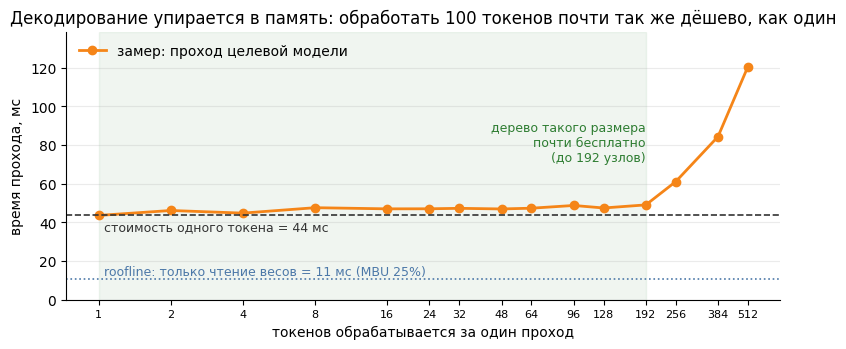

In [6]:
# --- График: стоимость прохода против числа токенов ---------------------------
xs = np.array(SIZES, dtype=float)
ys = np.array([roof[n] for n in SIZES])

fig, ax = plt.subplots(figsize=(8.0, 3.6))
ax.plot(xs, ys, "o-", color=C_EAGLE, lw=2, ms=6, label="замер: проход целевой модели")
ax.axhline(step_ms, color=C_INK, lw=1.2, ls="--")
# Подпись уходит ПОД пунктир: над ним лежит плоский участок самой кривой, а полоса
# между пунктиром и roofline пуста при любых данных — кривая туда не опускается.
ax.text(1.05, step_ms - (step_ms - predicted_ms) * 0.08,
        f"стоимость одного токена = {step_ms:.0f} мс",
        fontsize=9, color=C_INK, va="top")
ax.axhline(predicted_ms, color=C_NAIVE, lw=1.2, ls=":")
ax.text(1.05, predicted_ms * 1.06,
        f"roofline: только чтение весов = {predicted_ms:.0f} мс (MBU {mbu:.0f}%)",
        fontsize=9, color=C_NAIVE, va="bottom")
ax.axvspan(1, free_upto, color=C_OK, alpha=0.07)
# Выноску держим над плоским участком, а не над долей от максимума: максимум задаёт
# правый хвост, плоскость — время шага, и на другом железе они разъезжаются.
flat_max = ys[xs <= free_upto].max()
ax.text(free_upto, flat_max + (ys.max() - flat_max) * 0.45,
        f"  дерево такого размера\n  почти бесплатно\n  (до {free_upto} узлов)",
        fontsize=9, color=C_OK, ha="right", va="center")
ax.set_xscale("log", base=2); ax.set_xticks(SIZES)
ax.set_xticklabels([str(s) for s in SIZES], fontsize=8)
ax.set_xlabel("токенов обрабатывается за один проход")
ax.set_ylabel("время прохода, мс")
ax.set_ylim(0, ys.max() * 1.15)
ax.set_title("Декодирование упирается в память: обработать 100 токенов почти так же дёшево, как один")
ax.legend(frameon=False, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)
finish("roofline")


> **Вывод.** Кривая плоская почти до 192 токенов: обработать 100 токенов стоит почти столько же, сколько один. На этом запасе и работает спекулятивное декодирование. Второе наблюдение — расстояние до пунктирной линии: обычный шаг вчетверо дороже теоретического минимума, то есть запас есть и у самой обычной генерации, и часть будущего ускорения даст именно он.

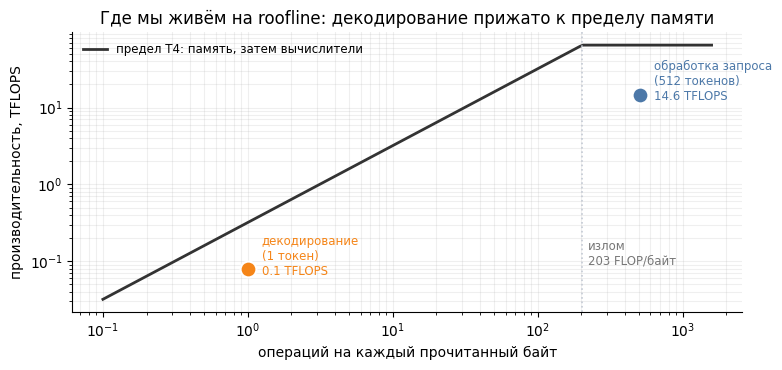

декодирование (1 токен)      операций на байт     1.0 |   0.1 TFLOPS из 65
обработка запроса (512 токенов) операций на байт   512.0 |  14.6 TFLOPS из 65


In [7]:
# --- Классическая roofline-диаграмма с нашими двумя рабочими точками -------------
# Считаем по замерам: сколько операций на прочитанный байт и какую производительность
# мы реально получаем в двух режимах — декодирование (1 токен) и обработка запроса (512).
flops_per_token = 2 * N_TARGET                      # умножение-накопление = 2 операции
bytes_weights   = N_TARGET * 2                      # fp16

points = {}
for n, label in ((1, "декодирование\n(1 токен)"), (512, "обработка запроса\n(512 токенов)")):
    sec = roof[n] / 1000
    points[label] = dict(
        intensity=flops_per_token * n / bytes_weights,   # операций на прочитанный байт
        achieved=flops_per_token * n / sec / 1e12)       # TFLOPS

ridge = GPU_FP16_TFLOPS * 1e12 / (GPU_BW_GBS * 1e9)      # точка излома roofline
xs_r = np.logspace(-1, 3.2, 200)
roof_y = np.minimum(xs_r * GPU_BW_GBS * 1e9 / 1e12, GPU_FP16_TFLOPS)

fig, ax = plt.subplots(figsize=(8.0, 3.8))
ax.plot(xs_r, roof_y, color=C_INK, lw=2, label="предел T4: память, затем вычислители")
ax.axvline(ridge, color=C_GRID, lw=1.2, ls=":")
ax.text(ridge * 1.1, 0.09, f"излом\n{ridge:.0f} FLOP/байт", fontsize=8.5, color="#777")
for (label, p), col in zip(points.items(), (C_EAGLE, C_NAIVE)):
    ax.scatter([p["intensity"]], [p["achieved"]], s=130, color=col, zorder=5,
               edgecolor="white", linewidth=1.5)
    ax.annotate(f"{label}\n{p['achieved']:.1f} TFLOPS", (p["intensity"], p["achieved"]),
                textcoords="offset points", xytext=(10, -4), fontsize=8.5, color=col)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("операций на каждый прочитанный байт")
ax.set_ylabel("производительность, TFLOPS")
ax.set_title("Где мы живём на roofline: декодирование прижато к пределу памяти")
ax.legend(frameon=False, fontsize=8.5, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.2, which="both")
finish("roofline_diagram")

for label, p in points.items():
    print(f"{label.replace(chr(10), ' '):28s} операций на байт {p['intensity']:7.1f} | "
          f"{p['achieved']:5.1f} TFLOPS из {GPU_FP16_TFLOPS:.0f}")


> **Вывод.** Декодирование одного токена живёт в левой части диаграммы — там, где производительность ограничена шиной памяти, а вычислители простаивают. Обработка запроса на 512 токенах сдвигается вправо на два порядка и упирается уже в другой предел. Спекулятивное декодирование двигает шаг генерации из левой зоны правее: за те же прочитанные байты выполняется больше полезной работы.

### Формула, к которой сводится весь разбор

**Длина принятия τ** — среднее число токенов, которые цикл выдаёт за один проход целевой модели: принятые черновики плюс бонусный токен, то есть в коде это `accept_length` + 1. У обычной генерации τ = 1 по определению: один проход, один токен.

Тогда выигрыш описывается так:

$$S \;\approx\; \frac{\tau \cdot t_{\mathrm{step}}}{t_{\mathrm{verify}} + (d+1) \cdot t_{\mathrm{draft}}}$$

Обозначения:

- $S$ — ускорение относительно обычной генерации;
- $\tau$ — длина принятия;
- $d$ — глубина дерева;
- $t_{\mathrm{step}}$ — время обычного шага генерации;
- $t_{\mathrm{verify}}$ — время проверки всего дерева за один проход целевой модели;
- $t_{\mathrm{draft}}$ — время одного шага черновой модели.

В числителе — сколько токенов приносит цикл, в знаменателе — во что он обходится. Дальше я измеряю по отдельности каждую величину: $t_{\mathrm{verify}}$ здесь и в [§8](#s8), $t_{\mathrm{draft}}$ в [§7](#s7) и [§8](#s8), $\tau$ в [§5](#s5). Все результаты разбора складываются в эту формулу, включая тот, где ускорение оказывается меньше единицы.


<div style="background-color:#fff4e6;border:2px solid #ffd8a8;border-radius:6px;padding:14px 16px;color:#111;font-size:15px">
<strong>Базовый вариант.</strong> Замеренный шаг примерно вчетверо
дороже roofline-предсказания: шина памяти загружена на четверть. Разница — это накладные расходы реализации:
attention без flash-ядер, пооперационный запуск CUDA-ядер из Python, отсутствие CUDA-графов.
Спекулятивное декодирование делит эти накладные расходы на τ принятых токенов. Поэтому <em>часть</em> ускорения,
которое я дальше измерю, объясняется не выигрышем по памяти, а амортизацией неоптимальности базового варианта.
На вылизанном стеке (vLLM, SGLang, CUDA-графы) обычный шаг ближе к пределу памяти, и ускорение
от спекуляции получается скромнее: независимые замеры на vLLM дают 1.3–2× там, где авторские
фреймворки показывают 4–6× ([«Performance or Illusion?», 2601.11580](https://arxiv.org/abs/2601.11580)).
<br><br>
Второе ограничение — batch = 1: я измеряю латентность. В проде важнее пропускная способность, а там картина другая: при большом батче
вычислители загружены и без всякой спекуляции, проверять черновики уже нечем, и выигрыш
схлопывается. В самой статье это видно: 4–6× при batch = 1 против 1.38× в
SGLang при batch = 64. Спекулятивное декодирование лечит decode и только его — обработка запроса
живёт на roofline правее и в лечении не нуждается.
</div>

<a id="s2"></a>
## 2. KV-кэш: цена памяти и почему дерево вообще возможно

Замер выше показал, что дерево проверяется почти даром. Осталось понять, где это дерево живёт между шагами и почему вообще может там жить.

Без кэша внимания генерация была бы квадратичной: каждый новый токен пересчитывал бы ключи и значения для всего префикса. KV-кэш хранит их и превращает шаг в линейный по длине контекста. Цена — память, и она считается точно.

Для нашей модели: 28 слоёв, 8 KV-голов против 16 голов внимания (GQA: вдвое экономнее обычного внимания), размер головы 128, 2 тензора (K и V), 2 байта на число.

Спекулятивное декодирование добавляет к этому требование, которого нет у обычной генерации. За один проход проверяется целое дерево, но принимается только один путь в нём. Значит, кэш должен уметь три вещи: пускать каждый узел смотреть только на своих предков (**tree attention** — маска, а не обычная каузальная), хранить K и V для всех узлов дерева сразу, а после проверки оставить только выигравший путь, выкинув остальные ветки без пересчёта.

В EAGLE это сделано без аллокаций в цикле: буфер под весь контекст выделяется один раз (`initialize_past_key_values`), а когда кандидат принят, его позиции копируются на своё место внутри того же буфера (`dst.copy_(tgt)` в `update_inference_inputs`), после чего указатель длины сдвигается. Корректность здесь держится на том, что K и V каждого узла считались с учётом только его предков — а значит, для принятого пути они ровно те же, какими были бы при обычном последовательном декодировании. Отброшенные ветки не оставляют следа.

Считаю, во что обходится кэш на этой модели и сколько занимает в нём дерево черновиков.

In [8]:
# --- Замер 2: арифметика KV-кэша ------------------------------------------------
kv_per_token = 2 * L * cfg.num_key_value_heads * cfg.head_dim * 2      # K и V, fp16
weights_gb = N_TARGET * 2 / 2**30

print(f"слоёв {L} | KV-голов {cfg.num_key_value_heads} (голов внимания {cfg.num_attention_heads}, "
      f"то есть GQA x{cfg.num_attention_heads // cfg.num_key_value_heads}) | head_dim {cfg.head_dim}")
print(f"KV на один токен: {kv_per_token/1024:.0f} КБ")
for ctx in (512, 2048, 8192, 40960):
    print(f"  контекст {ctx:6d} -> {kv_per_token*ctx/2**20:8.0f} МБ "
          f"({100*kv_per_token*ctx/2**30/weights_gb:5.1f}% от весов модели)")

# сколько КВ-памяти стоит само дерево
for tree in (32, 96, 256):
    print(f"дерево из {tree:3d} узлов держит в кэше {kv_per_token*tree/2**20:.1f} МБ — "
          f"меньше {100*kv_per_token*tree/2**30/weights_gb:.2f}% от весов")

print(f"\nвеса модели в fp16: {weights_gb:.2f} ГБ | занято на GPU сейчас: "
      f"{torch.cuda.memory_allocated()/2**30:.2f} ГБ")


слоёв 28 | KV-голов 8 (голов внимания 16, то есть GQA x2) | head_dim 128
KV на один токен: 112 КБ
  контекст    512 ->       56 МБ (  1.7% от весов модели)
  контекст   2048 ->      224 МБ (  6.8% от весов модели)
  контекст   8192 ->      896 МБ ( 27.3% от весов модели)
  контекст  40960 ->     4480 МБ (136.5% от весов модели)
дерево из  32 узлов держит в кэше 3.5 МБ — меньше 0.11% от весов
дерево из  96 узлов держит в кэше 10.5 МБ — меньше 0.32% от весов
дерево из 256 узлов держит в кэше 28.0 МБ — меньше 0.85% от весов

веса модели в fp16: 3.20 ГБ | занято на GPU сейчас: 4.07 ГБ


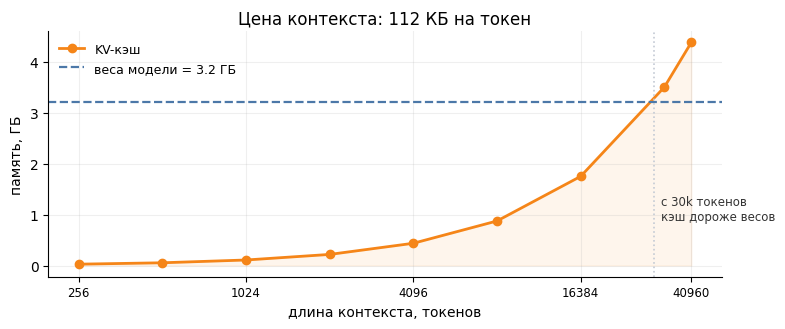

In [9]:
# --- KV-кэш против весов: когда контекст начинает стоить дороже модели ----------
ctxs = np.array([256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 40960])
kv_gb = kv_per_token * ctxs / 2**30

fig, ax = plt.subplots(figsize=(8.0, 3.4))
ax.plot(ctxs, kv_gb, "o-", color=C_EAGLE, lw=2, ms=6, label="KV-кэш")
ax.axhline(weights_gb, color=C_NAIVE, lw=1.6, ls="--",
           label=f"веса модели = {weights_gb:.1f} ГБ")
cross = weights_gb * 2**30 / kv_per_token
ax.axvline(cross, color=C_GRID, lw=1.2, ls=":")
ax.text(cross * 1.06, weights_gb * 0.28, f"с {cross/1000:.0f}k токенов\nкэш дороже весов",
        fontsize=8.5, color=C_INK)
ax.fill_between(ctxs, 0, kv_gb, color=C_EAGLE, alpha=0.08)
ax.set_xscale("log", base=2)
ticks = [256, 1024, 4096, 16384, 40960]
ax.set_xticks(ticks); ax.set_xticklabels([str(t) for t in ticks], fontsize=8.5)
ax.minorticks_off()
ax.set_xlabel("длина контекста, токенов")
ax.set_ylabel("память, ГБ")
ax.set_title(f"Цена контекста: {kv_per_token/1024:.0f} КБ на токен")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.2)
finish("kv_memory")


> **Вывод.** На коротком контексте KV-кэш почти незаметен, но растёт он линейно и на предельных для Qwen3 40 тысячах токенов обгоняет сами веса модели. Дерево черновиков на этом фоне бесплатно: сотня узлов занимает единицы мегабайт. Именно поэтому спекулятивное декодирование ничего не стоит по памяти — оно расходует то, чего в избытке, ради того, чего не хватает. И обратная сторона: на длинном контексте арифметика [§1](#s1) меняется, потому что шаг тащит уже и веса, и кэш, поэтому дорожают одновременно и обычная генерация, и проверка дерева. Все замеры этого разбора сняты на коротких запросах, где кэш ещё ничего не решает.

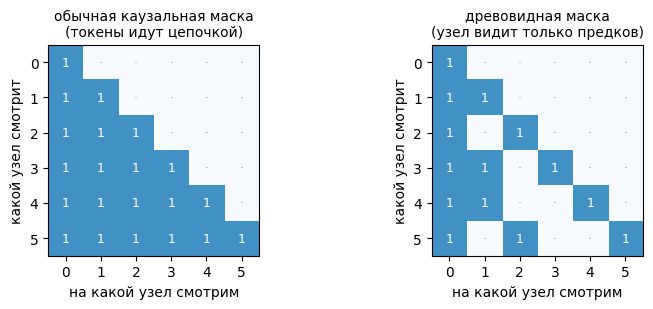

Дерево: 1<-0 2<-0 3<-1 4<-1 5<-2
Узлы 3 и 5 лежат в разных ветках и в древовидной маске друг друга не видят,
хотя в обычной каузальной маске узел 5 видел бы узел 3 просто потому, что тот раньше.


In [10]:
# --- Как выглядит маска дерева: каузальная против древовидной --------------------
# Возьмём маленькое дерево и посмотрим на его маску внимания.
demo_parent = [-1, 0, 0, 1, 1, 2]          # узел -> родитель, 0 = корень
n_demo = len(demo_parent)
mask_tree = np.zeros((n_demo, n_demo))
for i in range(n_demo):
    j = i
    while j != -1:
        mask_tree[i, j] = 1
        j = demo_parent[j]
mask_causal = np.tril(np.ones((n_demo, n_demo)))

fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.2))
for ax, m, ttl in ((axes[0], mask_causal, "обычная каузальная маска\n(токены идут цепочкой)"),
                   (axes[1], mask_tree, "древовидная маска\n(узел видит только предков)")):
    ax.imshow(m, cmap="Blues", vmin=0, vmax=1.6)
    for i in range(n_demo):
        for j in range(n_demo):
            ax.text(j, i, "1" if m[i, j] else "·", ha="center", va="center",
                    fontsize=9, color="white" if m[i, j] else "#99A")
    ax.set_title(ttl, fontsize=10)
    ax.set_xticks(range(n_demo)); ax.set_yticks(range(n_demo))
    ax.set_xlabel("на какой узел смотрим"); ax.set_ylabel("какой узел смотрит")
finish("tree_mask")

print("Дерево:", " ".join(f"{i}<-{p}" for i, p in enumerate(demo_parent) if p >= 0))
print("Узлы 3 и 5 лежат в разных ветках и в древовидной маске друг друга не видят,")
print("хотя в обычной каузальной маске узел 5 видел бы узел 3 просто потому, что тот раньше.")


> **Вывод.** Каузальная маска разрешает каждому токену смотреть на всё, что левее. Для цепочки это верно. В дереве так нельзя: узлы из разных веток лежат в одном тензоре, но представляют взаимоисключающие продолжения. Древовидная маска оставляет каждому узлу только его предков; без неё ветки перепутались бы, а проверка потеряла бы смысл.

<a id="s3"></a>
## 3. Что именно меняет EAGLE-3 — и что из этого видно в коде

Кэш умеет хранить дерево целиком и оставлять от него принятый путь. Теперь — чем третья версия метода отличается от первых двух и что из этого видно не в статье, а в коде.

EAGLE-3 — третья работа серии: EAGLE-1 (ICML’24), EAGLE-2 (EMNLP’24), EAGLE-3 (NeurIPS’25). Заявленное в ней ускорение до 6.5 раза — лучшая ячейка таблицы (HumanEval на Vicuna-13B); средние по моделям скромнее, 5.51 на Vicuna-13B и 4.44 на LLaMA-3.1-8B, и всё это при жадном декодировании, batch = 1 и в собственном фреймворке авторов. Там же есть вторая цифра, и измеряет она другое: в SGLang при batch = 64 прирост пропускной способности составляет 1.38 раза.

**EAGLE-1** ([2401.15077](https://arxiv.org/abs/2401.15077)) заметил, что предсказывать следующий токен маленькой моделью тяжело, а предсказывать **признак** — скрытое состояние верхнего слоя целевой модели — заметно легче: признаки регулярнее токенов. Черновая модель там устроена как один трансформерный слой, который получает на вход признак `f_t` и эмбеддинг уже известного токена `x_{t+1}`, а затем авторегрессивно продолжает цепочку признаков. Второй вход снимает неопределённость сэмплирования: черновая модель знает, какой токен на самом деле выпал.

**EAGLE-2** ([2406.16858](https://arxiv.org/abs/2406.16858)) сделал дерево черновиков динамическим. Раньше форма дерева была фиксированной; теперь узлы раскрываются по уверенности черновой модели, и в дерево отбираются `total_token` лучших по кумулятивной логарифмической вероятности. Там, где черновая модель уверена, дерево растёт вглубь; где сомневается — вширь.

**EAGLE-3** ([2503.01840](https://arxiv.org/abs/2503.01840)) вносит три изменения:

1. **Черновая модель перестаёт предсказывать признак.** Раньше в лоссе был член `l_fea` — регрессия на признак целевой модели. Он работал как регуляризатор и упирался в потолок: качество черновой модели переставало расти с объёмом обучающих данных. EAGLE-3 обучает черновую модель только предсказывать токены и получает главный результат статьи: длина принятия начинает расти с объёмом данных. Тонкость: авторегрессия по признакам никуда не делась, черновая модель по-прежнему передаёт своё скрытое состояние на следующий шаг. Ушёл именно лосс, который заставлял это состояние совпадать с признаком целевой модели.
2. **Слияние трёх уровней.** Вместо одного признака с верхнего слоя — конкатенация скрытых состояний с низкого, среднего и верхнего слоёв, сжатая линейным слоем 3h → h. Верхний признак заточен под ближайший токен и теряет информацию, полезную на несколько шагов вперёд.
3. **Training-time test.** При генерации черновая модель идёт по цепочке собственных выходов, которых она при обучении не видела, и накапливает дрейф. EAGLE-3 при обучении раскатывает черновую модель на её собственных предсказаниях, имитируя инференс. Ближайший предок идеи — HASS ([2408.15766](https://arxiv.org/abs/2408.15766)).

Три подробности, которых в статье нет, а в загруженных весах видны сразу: с каких именно слоёв берутся признаки, насколько урезан словарь черновой модели и какой параметр остался в коде нерабочим.

In [11]:
# --- Что внутри черновой головы ----------------------------------------------------
ea = model.ea_layer
draft_vocab = ea.config.draft_vocab_size
full_vocab  = ea.config.vocab_size
head_params = draft_vocab * ea.config.hidden_size

print("1) Слои целевой модели, с которых берётся слияние (в коде: idx == 2, L//2, L-3):")
print(f"   низкий 2 | средний {L//2} | верхний {L-3}   из {L} слоёв")
print(f"   fc: {tuple(ea.fc.weight.shape)} — сжимает 3h -> h\n")

print("2) Усечённый словарь черновой модели — не деталь, а условие применимости:")
print(f"   словарь целевой модели {full_vocab}, словарь черновой модели {draft_vocab}")
print(f"   lm_head черновой модели: {head_params/1e6:.0f}M параметров = "
      f"{100*head_params/N_DRAFT:.0f}% всей головы")
full_head = full_vocab * ea.config.hidden_size
print(f"   с полным словарём голова весила бы {(N_DRAFT - head_params + full_head)/1e6:.0f}M "
      f"= {100*(N_DRAFT - head_params + full_head)/N_TARGET:.0f}% от целевой модели "
      f"(вместо {100*N_DRAFT/N_TARGET:.1f}%)")
print("   то есть на таком маленьком целевой модели EAGLE-3 без усечения словаря не окупилась бы\n")

print("3) Как связаны словари (d2t хранит СМЕЩЕНИЯ, а не индексы):")
print(f"   d2t: {tuple(ea.d2t.shape)} {ea.d2t.dtype}, "
      f"применяется как token = i + d2t[i]")
print(f"   t2d: {tuple(ea.t2d.shape)} {ea.t2d.dtype} — маска покрытия словаря целевой модели")
print(f"   покрыто токенов целевой модели: {int(ea.t2d.sum())} из {full_vocab}")
print("   токен вне draft-словаря черновая модель предложить не может, но целевая модель его")
print("   свободно выдаёт бонусным токеном — на корректность это не влияет\n")

print("4) Параметр threshold: живёт в конструкторе, но в EAGLE-3-ветке не используется.")
import inspect, re as _re
src_topk = inspect.getsource(type(ea).topK_genrate)
print(f"   self.threshold задан в __init__, упоминаний в topK_genrate: "
      f"{len(_re.findall(r'threshold', src_topk))}")
print("   (в cnets1.py — черновая модель EAGLE-1/2 — он ещё работал как порог отсечения)")


1) Слои целевой модели, с которых берётся слияние (в коде: idx == 2, L//2, L-3):
   низкий 2 | средний 14 | верхний 25   из 28 слоёв
   fc: (2048, 6144) — сжимает 3h -> h

2) Усечённый словарь черновой модели — не деталь, а условие применимости:
   словарь целевой модели 151936, словарь черновой модели 32000
   lm_head черновой модели: 66M параметров = 48% всей головы
   с полным словарём голова весила бы 382M = 22% от целевой модели (вместо 8.0%)
   то есть на таком маленьком целевой модели EAGLE-3 без усечения словаря не окупилась бы

3) Как связаны словари (d2t хранит СМЕЩЕНИЯ, а не индексы):
   d2t: (32000,) torch.int64, применяется как token = i + d2t[i]
   t2d: (151936,) torch.bool — маска покрытия словаря целевой модели
   покрыто токенов целевой модели: 32000 из 151936
   токен вне draft-словаря черновая модель предложить не может, но целевая модель его
   свободно выдаёт бонусным токеном — на корректность это не влияет

4) Параметр threshold: живёт в конструкторе, но в EAGLE-3

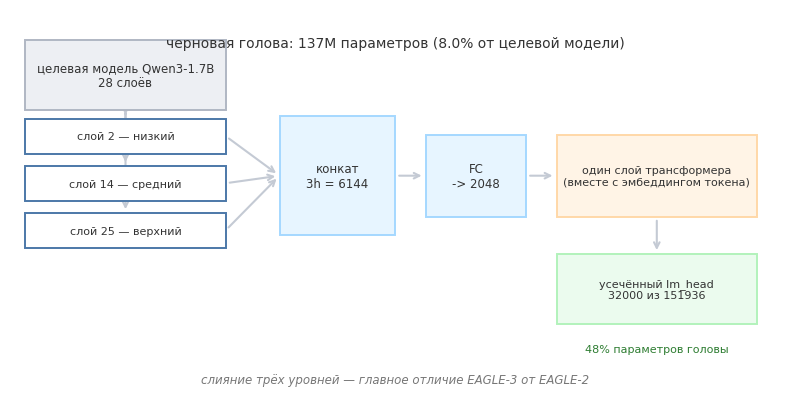

In [12]:
# --- Схема черновой головы EAGLE-3 --------------------------------------------------
fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.set_xlim(0, 10); ax.set_ylim(0, 6.2); ax.axis("off")

def box(x, y, w, h, text, fc, ec, fs=8.5, tc=C_INK):
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=fc, edgecolor=ec,
                               linewidth=1.4, zorder=2))
    ax.text(x + w/2, y + h/2, text, ha="center", va="center",
            fontsize=fs, color=tc, zorder=3)

def arrow(x1, y1, x2, y2, color=C_GRID):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", color=color, lw=1.5,
                                shrinkA=3, shrinkB=3), zorder=1)

# целевая модель и три отвода
box(0.2, 4.6, 2.6, 1.1, f"целевая модель Qwen3-1.7B\n{L} слоёв", "#EDEFF3", "#B0B7C3")
lay = [(2, "низкий"), (L//2, "средний"), (L-3, "верхний")]
for k, (idx, name) in enumerate(lay):
    y = 3.9 - k * 0.75
    box(0.2, y, 2.6, 0.55, f"слой {idx} — {name}", "#FFFFFF", C_NAIVE, fs=8)
    arrow(1.5, 4.6, 1.5, y + 0.55)

box(3.5, 2.6, 1.5, 1.9, f"конкат\n3h = {3*ea.config.hidden_size}", "#E7F5FF", "#A5D8FF")
for k in range(3):
    arrow(2.8, 3.9 - k*0.75 + 0.28, 3.5, 3.55)
box(5.4, 2.9, 1.3, 1.3, f"FC\n-> {ea.config.hidden_size}", "#E7F5FF", "#A5D8FF")
arrow(5.0, 3.55, 5.4, 3.55)
box(7.1, 2.9, 2.6, 1.3, "один слой трансформера\n(вместе с эмбеддингом токена)",
    "#FFF4E6", "#FFD8A8", fs=8)
arrow(6.7, 3.55, 7.1, 3.55)
box(7.1, 1.2, 2.6, 1.1,
    f"усечённый lm_head\n{ea.config.draft_vocab_size} из {ea.config.vocab_size}",
    "#EBFBEE", "#B2F2BB", fs=8)
arrow(8.4, 2.9, 8.4, 2.3)
ax.text(8.4, 0.75, f"{100*head_params/N_DRAFT:.0f}% параметров головы", ha="center",
        fontsize=8, color=C_OK)
ax.text(5.0, 5.6, f"черновая голова: {N_DRAFT/1e6:.0f}M параметров "
        f"({100*N_DRAFT/N_TARGET:.1f}% от целевой модели)", ha="center", fontsize=10, color=C_INK)
ax.text(5.0, 0.25, "слияние трёх уровней — главное отличие EAGLE-3 от EAGLE-2",
        ha="center", fontsize=8.5, color="#777", style="italic")
finish("draft_head")


> **Вывод.** Черновая модель устроена куда проще целевой модели: три отвода скрытых состояний, линейное сжатие, один слой трансформера и выходной словарный слой. Почти половину всех её параметров занимает как раз этот слой, и он усечён до 32 тысяч токенов вместо полного словаря: без урезания черновая модель весила бы пятую часть целевой и на ней бы не окупилась.

<a id="s4"></a>
## 4. Запуск: три способа генерации на одной модели

Сначала про код и веса. Код я беру из официального репозитория [SafeAILab/EAGLE](https://github.com/SafeAILab/EAGLE) на коммите `cb7e0841` — оттуда же `eagenerate`, `naivegenerate`, построение дерева и наборы вопросов. Черновую голову беру ту, которую этот же репозиторий указывает в своей таблице весов для Qwen3-1.7B: [AngelSlim/Qwen3-1.7B_eagle3](https://huggingface.co/AngelSlim/Qwen3-1.7B_eagle3). В таблице она помечена как неавторская — обучила её команда [AngelSlim](https://github.com/Tencent/AngelSlim) в Tencent: у самих авторов EAGLE готовые головы есть только под Vicuna и LLaMA. Для чтения цифр это важнее, чем кажется: голова обучена на англоязычных диалогах и вне своего домена ведёт себя совсем иначе ([§5](#s5)).

Все три работают с одними и теми же весами: модель одна, различается только цикл, который её вызывает.

**`generate` из `transformers`** — то, что получает обычный пользователь. Это честный внешний ориентир, но у него другой бэкенд внимания и другой кэш, поэтому он не изолирует эффект спекуляции.

**`naivegenerate`** — обычный цикл генерации из репозитория EAGLE (в статьях его называют vanilla autoregressive): та же модифицированная модель, тот же статический KV-буфер, что и у спекулятивного цикла. Относительно него статья и считает свои ускорения, и он же изолирует вклад метода: между ним и `eagenerate` одно отличие — спекуляция.

**`eagenerate`** — собственно EAGLE-3.

Дальше все цифры я привожу к обоим базовым вариантам сразу. Неприятная сторона: `naivegenerate` на нашей карте оказывается медленнее штатного `generate` примерно на 10% — он не использует flash-attention. Значит, ускорение к нему слегка льстит методу. Поэтому в итоговой таблице стоят обе колонки.

Все три останавливаются по EOS, а тексты у них расходятся (об этом [§10](#s10)), поэтому скорость в токенах в секунду считалась бы на разной работе. Чтобы сравнение было честным, в замерах я подавляю конец последовательности и заставляю каждый способ выдать одинаковое число токенов.

Ниже — общая обвязка замеров: единый способ собрать запрос, секундомер вокруг генерации и переключатель формы дерева. Там же живёт подавление конца последовательности, о котором сказано абзацем выше.

In [13]:
# --- Утилиты замера: одинаковая работа для всех трёх способов -------------------
from transformers import AutoModelForCausalLM

def encode(question, thinking=False):
    text = tok.apply_chat_template(
        [{"role": "user", "content": question}],
        tokenize=False, add_generation_prompt=True, enable_thinking=thinking)
    return torch.as_tensor(tok([text]).input_ids).cuda()

class NoEOS:
    """Подавляет остановку по EOS: все три способа выдают ровно N токенов.

    Без этого EAGLE и обычная генерация останавливаются в разных местах и делят разное
    число токенов на разное время, то есть сравнивают разную работу.
    """
    def __enter__(self):
        self._saved = model.tokenizer.eos_token_id
        model.tokenizer.eos_token_id = -1          # такого id в выдаче не бывает
        return self
    def __exit__(self, *a):
        model.tokenizer.eos_token_id = self._saved

def run_naive(ids, n_tokens):
    with NoEOS():
        (out, new, _), dt = timed(model.naivegenerate, ids, temperature=0.0,
                                  max_new_tokens=n_tokens, log=True)
    return dict(tokens=int(new), sec=dt, steps=int(new), ids=out)

def run_eagle(ids, n_tokens):
    with NoEOS():
        (out, new, idx), dt = timed(model.eagenerate, ids, temperature=0.0,
                                    max_new_tokens=n_tokens, log=True)
    return dict(tokens=int(new), sec=dt, steps=idx + 1, ids=out)

def ms_per_token(r):
    return 1000 * r["sec"] / r["tokens"]

def set_tree(total_token, depth, top_k):
    """Форма дерева — обычные атрибуты черновой модели, модель перезагружать не нужно."""
    model.ea_layer.top_k = top_k
    model.ea_layer.depth = depth
    model.ea_layer.total_tokens = total_token - 1
    model.ea_layer.init_tree()

WARM = encode("Explain in two sentences why the sky is blue.")
with torch.no_grad():
    run_eagle(WARM, 32); run_naive(WARM, 32)


<a id="s5"></a>
## 5. Бенчмарк на наборах из статьи

Три способа готовы, нужен честный набор задач. Самодельные запросы — слабое место любого замера скорости: их всегда можно подобрать под удобный ответ. К счастью, репозиторий EAGLE везёт с собой ровно те наборы, на которых считает статью: MT-Bench (диалог), GSM8K (арифметические задачи), HumanEval (код), Alpaca (инструкции) — по 80 вопросов каждый. Беру из каждого первые пять: полный прогон по 320 вопросам в бесплатную сессию не влезает.

Пятый набор я написал сам: пять русскоязычных запросов, никакого публичного бенчмарка. Черновая голова обучена сообществом на англоязычных данных, и мне интересен режим, в котором метод работает вне своего домена. Как увидим, он и даёт единственный отрицательный результат разбора.

Порядок вызовов внутри вопроса фиксирован — сначала штатный `generate`, потом `naivegenerate`, потом `eagenerate`; рандомизации нет. Все три запускаются подряд на одном вопросе, поэтому нагрев карты действует на них почти одинаково: разброс обычной генерации между повторами составляет доли процента ([§7](#s7) печатает его явно).

Числа этого раздела сняты на стартовой форме дерева `60/7/10` (total_token / depth / top_k), заданной при загрузке модели. В [§7](#s7) выяснится, что эта форма не оптимальна: более мелкое дерево заметно выигрывает. [§7](#s7) печатает и срез, и победившую форму сам, а точная цифра гуляет между прогонами. Полный бенчмарк на выбранной форме я не прогонял: сессия Kaggle не резиновая, а вывод раздела — про разрыв между доменами в два с половиной раза — это отношение двух ускорений, снятых на одной форме, так что общий сдвиг из него сокращается.

Собираю пять наборов: четыре из репозитория статьи и свой русскоязычный.

In [14]:
# --- Наборы вопросов -------------------------------------------------------------
BENCH_DIR = "/kaggle/working/EAGLE/eagle/data"
N_Q   = 3 if QUICK else 5          # вопросов из каждого набора
N_TOK = 128 if QUICK else 192      # ровно столько новых токенов на каждый прогон

def load_bench(name):
    with open(f"{BENCH_DIR}/{name}/question.jsonl") as f:
        return [json.loads(l)["turns"][0] for l in f]

BENCH = {
    "MT-Bench":  load_bench("mt_bench")[:N_Q],
    "GSM8K":     load_bench("gsm8k")[:N_Q],
    "HumanEval": load_bench("humaneval")[:N_Q],
    "Alpaca":    load_bench("alpaca")[:N_Q],
    "Русский":  [
        "Объясни в трёх предложениях, почему небо голубое.",
        "Напиши функцию на Python, которая проверяет, является ли строка палиндромом.",
        "Составь короткое деловое письмо с просьбой перенести встречу.",
        "Реши задачу по шагам: в корзине 48 яблок, треть раздали. Сколько осталось?",
        "Перечисли пять городов Золотого кольца и чем известен каждый.",
    ][:N_Q],
}
assert LANG_SET in BENCH, "LANG_SET должен совпадать с ключом BENCH"
for k, v in BENCH.items():
    print(f"{k:10s}: {len(v)} вопросов | первый: {v[0][:64]!r}")


MT-Bench  : 5 вопросов | первый: 'Compose an engaging travel blog post about a recent trip to Hawa'
GSM8K     : 5 вопросов | первый: "Darrell and Allen's ages are in the ratio of 7:11. If their tota"
HumanEval : 5 вопросов | первый: 'Complete the code I provided.\n\ndef below_threshold(l: list, t: i'
Alpaca    : 5 вопросов | первый: 'What would be the best type of exercise for a person who has art'
Русский   : 5 вопросов | первый: 'Объясни в трёх предложениях, почему небо голубое.'


Отсюда берутся все числа [§5](#s5): каждый способ выдаёт фиксированное число токенов, и время делится на них.

In [15]:
# --- Основной замер: три способа подряд на одном вопросе, одинаковая работа ------
hf = AutoModelForCausalLM.from_pretrained(
    BASE_PATH, torch_dtype=torch.float16, device_map={"": 0}).eval()
with torch.no_grad():
    hf.generate(WARM, max_new_tokens=32, do_sample=False, min_new_tokens=32,
                temperature=None, top_p=None, top_k=None)

rows = []
for bench_name, questions in BENCH.items():
    for qi, q in enumerate(questions):
        ids = encode(q)
        # три способа подряд на одном вопросе -> дрейф карты бьёт по всем одинаково
        with torch.no_grad():
            out, dt = timed(hf.generate, ids, max_new_tokens=N_TOK, min_new_tokens=N_TOK,
                            do_sample=False, temperature=None, top_p=None, top_k=None)
        n_hf = out.shape[1] - ids.shape[1]
        r_nv = run_naive(ids, N_TOK)
        r_ea = run_eagle(ids, N_TOK)
        rows.append(dict(
            bench=bench_name, q=qi,
            hf_ms=1000 * dt / n_hf,
            naive_ms=ms_per_token(r_nv),
            eagle_ms=ms_per_token(r_ea),
            tau=r_ea["tokens"] / r_ea["steps"],
        ))
        print(f"{bench_name:10s} q{qi}: naive {rows[-1]['naive_ms']:5.1f} мс/ток | "
              f"eagle {rows[-1]['eagle_ms']:5.1f} мс/ток | τ {rows[-1]['tau']:4.2f}")

del hf
gc.collect(); torch.cuda.empty_cache()

bench_df = pd.DataFrame(rows)
bench_df["speedup_naive"] = bench_df.naive_ms / bench_df.eagle_ms
bench_df["speedup_hf"]    = bench_df.hf_ms / bench_df.eagle_ms


MT-Bench   q0: naive  46.4 мс/ток | eagle  26.8 мс/ток | τ 2.55
MT-Bench   q1: naive  46.5 мс/ток | eagle  18.2 мс/ток | τ 3.78
MT-Bench   q2: naive  46.1 мс/ток | eagle  23.5 мс/ток | τ 2.92
MT-Bench   q3: naive  46.3 мс/ток | eagle  24.6 мс/ток | τ 2.74
MT-Bench   q4: naive  46.0 мс/ток | eagle  26.9 мс/ток | τ 2.54
GSM8K      q0: naive  46.4 мс/ток | eagle  18.4 мс/ток | τ 3.75
GSM8K      q1: naive  46.1 мс/ток | eagle  20.9 мс/ток | τ 3.25
GSM8K      q2: naive  46.3 мс/ток | eagle  15.4 мс/ток | τ 4.43
GSM8K      q3: naive  46.8 мс/ток | eagle  20.8 мс/ток | τ 3.27
GSM8K      q4: naive  46.7 мс/ток | eagle  18.6 мс/ток | τ 3.68
HumanEval  q0: naive  45.8 мс/ток | eagle  15.9 мс/ток | τ 4.29
HumanEval  q1: naive  45.4 мс/ток | eagle  19.3 мс/ток | τ 3.50
HumanEval  q2: naive  45.7 мс/ток | eagle  20.4 мс/ток | τ 3.33
HumanEval  q3: naive  46.4 мс/ток | eagle  17.5 мс/ток | τ 4.02
HumanEval  q4: naive  47.2 мс/ток | eagle  17.7 мс/ток | τ 3.98
Alpaca     q0: naive  46.3 мс/ток | eagl

Свожу замеры по наборам. Разброс между вопросами внутри набора показываю рядом со средним: без него непонятно, отличается ли один набор от другого или это шум.

In [16]:
# --- Сводка по наборам с разбросом ----------------------------------------------
summary = bench_df.groupby("bench").agg(
    tau=("tau", "mean"),
    tau_min=("tau", "min"), tau_max=("tau", "max"),
    speedup=("speedup_naive", "mean"),
    sp_min=("speedup_naive", "min"), sp_max=("speedup_naive", "max"),
    speedup_hf=("speedup_hf", "mean"),
).reindex(list(BENCH.keys())).round(2)
def show_table(df):
    """Kaggle рендерит таблицы мельче основного текста — задаём кегль явно."""
    return df.style.set_table_styles(
        [{"selector": "th", "props": [("font-size", "13px")]}]
    ).set_properties(**{"font-size": "13px"})

display(show_table(summary))

overall_tau = bench_df.tau.mean()
overall_sp  = bench_df.speedup_naive.mean()
print(f"Итого по всем наборам: τ = {overall_tau:.2f}, "
      f"ускорение {overall_sp:.2f}x к naivegenerate, "
      f"{bench_df.speedup_hf.mean():.2f}x к штатному generate")
eng = bench_df[bench_df.bench != LANG_SET]
rus = bench_df[bench_df.bench == LANG_SET]
print(f"  английские наборы: τ = {eng.tau.mean():.2f}, ускорение {eng.speedup_naive.mean():.2f}x")
print(f"  русскоязычный набор:     τ = {rus.tau.mean():.2f}, ускорение {rus.speedup_naive.mean():.2f}x")


,tau,tau_min,tau_max,speedup,sp_min,sp_max,speedup_hf
bench,,,,,,,
MT-Bench,2.910000,2.540000,3.780000,1.970000,1.710000,2.560000,1.770000
GSM8K,3.680000,3.250000,4.430000,2.500000,2.210000,3.000000,2.220000
HumanEval,3.820000,3.330000,4.290000,2.560000,2.240000,2.880000,2.270000
Alpaca,3.190000,2.710000,3.710000,2.150000,1.830000,2.460000,1.940000
Русский,1.380000,1.120000,1.740000,0.950000,0.770000,1.210000,0.850000


Итого по всем наборам: τ = 3.00, ускорение 2.03x к naivegenerate, 1.81x к штатному generate
  английские наборы: τ = 3.40, ускорение 2.30x
  русскоязычный набор:     τ = 1.38, ускорение 0.95x


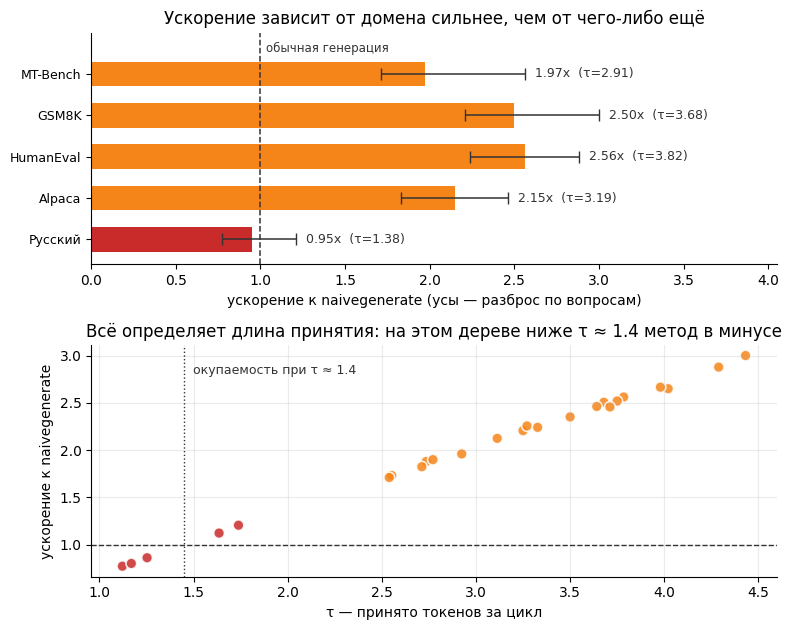

In [17]:
# --- График: ускорение по наборам, с разбросом по вопросам ----------------------
order = list(BENCH.keys())
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8.0, 6.4))

y = np.arange(len(order))
means = [summary.loc[b, "speedup"] for b in order]
lo = [summary.loc[b, "speedup"] - summary.loc[b, "sp_min"] for b in order]
hi = [summary.loc[b, "sp_max"] - summary.loc[b, "speedup"] for b in order]
colors = [C_EAGLE if b != LANG_SET else "#C92A2A" for b in order]
ax1.barh(y, means, xerr=[lo, hi], height=0.6, color=colors, edgecolor="none",
         error_kw=dict(ecolor=C_INK, lw=1.1, capsize=4))
ax1.axvline(1.0, color=C_INK, lw=1.1, ls="--")
for i, b in enumerate(order):
    ax1.text(summary.loc[b, "sp_max"] + 0.06, i,
             f'{means[i]:.2f}x  (τ={summary.loc[b, "tau"]:.2f})',
             va="center", fontsize=9, color=C_INK)
ax1.set_yticks(y); ax1.set_yticklabels(order, fontsize=9)
ax1.set_xlabel("ускорение к naivegenerate (усы — разброс по вопросам)")
ax1.set_xlim(0, max(summary.sp_max) * 1.35)
ax1.set_ylim(len(order) - 0.4, -1.0)
ax1.text(1.03, -0.62, "обычная генерация", fontsize=8.5, color=C_INK, va="center")
ax1.set_title("Ускорение зависит от домена сильнее, чем от чего-либо ещё")
ax1.spines[["top", "right"]].set_visible(False)

ax2.scatter(bench_df.tau, bench_df.speedup_naive,
            c=[C_EAGLE if b != LANG_SET else "#C92A2A" for b in bench_df.bench],
            s=60, alpha=0.85, edgecolor="white", linewidth=1.2)
ax2.axhline(1.0, color=C_INK, lw=1.0, ls="--")
# где кривая пересекает единицу: линейная подгонка по замерам
_fit = np.polyfit(bench_df.tau, bench_df.speedup_naive, 1)
tau_break = (1.0 - _fit[1]) / _fit[0]
ax2.axvline(tau_break, color=C_INK, lw=1.0, ls=":")
ax2.text(tau_break + 0.05, bench_df.speedup_naive.max() * 0.97,
         f"окупаемость при τ ≈ {tau_break:.1f}", fontsize=9, color=C_INK, va="top")
ax2.set_xlabel("τ — принято токенов за цикл")
ax2.set_ylabel("ускорение к naivegenerate")
ax2.set_title(f"Всё определяет длина принятия: на этом дереве ниже τ ≈ {tau_break:.1f} метод в минусе")
ax2.spines[["top", "right"]].set_visible(False)
ax2.grid(alpha=0.25)
finish("bench_by_domain")


> **Вывод.** Домен решает всё. На англоязычных наборах длина принятия держится около 3.4, и метод ускоряет вдвое с лишним; на русскоязычных она падает примерно до 1.4, и на этой — стартовой, глубокой — форме дерева та же машинерия начинает проигрывать обычной генерации. Разброс между вопросами внутри набора заметно меньше разрыва между наборами — значит, дело в домене, а не в отдельных неудачных запросах. Правый график показывает механику: ускорение почти линейно по длине принятия, и ниже точки окупаемости, отмеченной на графике, кривая уходит под единицу.

<div style="background-color:#fff4e6;border:2px solid #ffd8a8;border-radius:6px;padding:14px 16px;color:#111;font-size:15px">
<strong>Что это значит на практике.</strong> На англоязычных наборах метод даёт стабильное ускорение,
на русскоязычных — <em>замедляет</em> генерацию. Этот набор одновременно и вне домена черновой головы, и на
другом языке — разделить два обстоятельства этот прогон не может. Голову обучало сообщество на
англоязычных диалогах, так что данные обучения — причина вероятная. Проверить её мог бы англоязычный
набор вне домена или голова, обученная на русскоязычных данных; ни того ни другого здесь нет. Так или иначе, вне своего
домена она угадывает редко, τ падает почти до единицы, и цикл «построить дерево → проверить → отбросить»
вырождается в чистые накладные расходы поверх обычного шага.
<br><br>
Только замер снят на <em>стартовой</em> форме дерева, а она глубокая. На форме, которую выбирает <a href="#s7">§7</a>, замедления уже нет: <a href="#scaling">§11</a> прогоняет подмножество тех же запросов и
получает небольшой плюс. Значит, замедление — свойство не одного лишь домена, а домена и глубины вместе. Тот же срез по
глубине <a href="#s7">§7</a> снимает и на русскоязычном наборе: кривая там пересекает единицу.
<br><br>
Спекулятивное декодирование гарантирует качество, но не гарантирует выигрыш: длину принятия надо
измерять на своём распределении запросов, а не брать из статьи.
</div>

<a id="s6"></a>
## 6. Дерево черновиков: анатомия одного шага

Посмотрю на одно дерево целиком.

Форма дерева задаётся тремя параметрами:

- `top_k` задаёт ширину: сколько продолжений раскрывается у каждого узла;
- `depth` задаёт, сколько шагов расширения идёт после первого прохода черновой модели: цикл стоит `depth` + 1 запусков, и в дереве `depth` + 1 уровней;
- `total_token` задаёт бюджет: сколько узлов из всех раскрытых остаётся в дереве.

Строится оно так. Черновая модель делает один проход, потом ещё `depth` шагов; на каждом шаге у каждого из top-k текущих узлов раскрываются свои top-k продолжений, и получается пул кандидатов. Каждому приписана кумулятивная логарифмическая вероятность — сумма по всему пути от корня. Из пула отбираются `total_token` лучших по этой сумме, и уже по ним собираются древовидная маска и позиционные индексы. Динамический отбор — вклад EAGLE-2: у EAGLE-1 форма дерева задавалась заранее и не зависела от контекста.

Целевая модель проверяет всё дерево за один проход с древовидной маской из [§2](#s2). Из её логитов извлекаются все корневые пути; при жадном декодировании путь принимается ровно до той позиции, где очередной черновик перестал совпадать с `argmax` целевой модели. К принятому пути добавляется **бонусный токен** — тот, который целевая модель предсказала сама на последней принятой позиции. Поэтому даже при нулевом принятии цикл выдаёт один токен, как обычная генерация, и метод не может быть хуже по числу проходов целевой модели.

Ниже — инструментированная копия цикла: та же логика, но с записью дерева и результата проверки на каждом шаге.

Чтобы увидеть дерево, повторяю цикл генерации построчно и на каждом шаге сохраняю его состав, древовидную маску и то, какой путь прошёл проверку. 

In [18]:
# --- Инструментированный цикл: записываем каждое дерево -------------------------
from eagle.model.utils import (initialize_tree, tree_decoding, evaluate_posterior,
                               update_inference_inputs, reset_tree_mode)
from eagle.model.kv_cache import initialize_past_key_values

@torch.no_grad()
def eagenerate_traced(ids, max_new_tokens=96, max_length=2048):
    """Зеркало EaModel.eagenerate (жадный режим) + запись трейса по шагам."""
    padding = (torch.zeros(1, 1, dtype=torch.long) - 1).to(ids.device)
    input_ids = ids.clone()
    model.ea_layer.reset_kv()

    if hasattr(model, "past_key_values"):
        past_key_values = model.past_key_values
        past_key_values_data = model.past_key_values_data
        current_length_data = model.current_length_data
        current_length_data.zero_()
    else:
        (past_key_values, past_key_values_data,
         current_length_data) = initialize_past_key_values(model.base_model, max_length=max_length)
        model.past_key_values = past_key_values
        model.past_key_values_data = past_key_values_data
        model.current_length_data = current_length_data

    reset_tree_mode(model)
    draft_tokens, retrieve_indices, tree_mask, tree_position_ids, logits, hidden_state, sample_token = \
        initialize_tree(input_ids, model, past_key_values, None)

    trace, new_token = [], 0
    for _ in range(max_length - model.ea_layer.total_tokens - 10):
        model.base_model.model.tree_mask = tree_mask
        draft_tokens = draft_tokens.to(input_ids.device)
        step = {
            "nodes": draft_tokens[0].tolist(),
            "ancestors": tree_mask[0, 0].bool().cpu().numpy(),
            "depths": tree_position_ids.cpu().tolist(),
            "paths": retrieve_indices.cpu().tolist(),
        }
        logits, hidden_state_new, outputs = tree_decoding(
            model, draft_tokens, past_key_values, tree_position_ids, input_ids, retrieve_indices)
        draft_tokens_p = torch.cat((draft_tokens, padding), dim=1)
        candidates = draft_tokens_p[0, retrieve_indices]
        best_candidate, accept_length, sample_p = evaluate_posterior(logits, candidates, None)

        step["best_path"] = int(best_candidate)
        step["accept_length"] = int(accept_length)
        step["accepted_nodes"] = retrieve_indices[best_candidate][:accept_length + 1].tolist()
        step["bonus_token"] = int(torch.argmax(sample_p))
        trace.append(step)

        input_ids, draft_tokens, retrieve_indices, tree_mask, tree_position_ids, new_token, hidden_state, sample_token = \
            update_inference_inputs(input_ids, candidates, best_candidate, accept_length,
                                    retrieve_indices, None, new_token, past_key_values_data,
                                    current_length_data, model, hidden_state_new, sample_p)
        if new_token > max_new_tokens:
            break
    return input_ids, trace

set_tree(16, 5, 3)      # для рисунка нужно дерево поменьше, иначе подписи слипаются
TRACE_Q = BENCH["MT-Bench"][0]
_, trace = eagenerate_traced(encode(TRACE_Q), max_new_tokens=96)
acc = [s["accept_length"] + 1 for s in trace]
print(f"шагов {len(trace)}, выдано {sum(acc)} токенов, τ = {np.mean(acc):.2f}")
print("принято за цикл:", acc)


шагов 43, выдано 98 токенов, τ = 2.28
принято за цикл: [2, 1, 3, 3, 2, 2, 1, 3, 1, 4, 2, 1, 3, 2, 1, 2, 1, 3, 1, 2, 2, 4, 3, 2, 2, 2, 5, 2, 2, 1, 3, 1, 5, 2, 1, 1, 3, 3, 5, 1, 4, 2, 2]


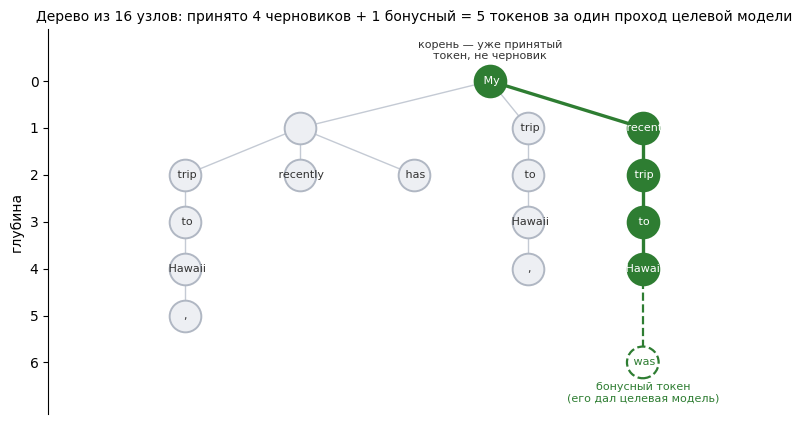

Пути этого дерева (первые 6):
  [отвергнут]  My ->   ->  recently
  [отвергнут]  My ->   ->  has
  [ПРИНЯТ   ]  My ->  recent ->  trip ->  to ->  Hawaii
  [отвергнут]  My ->  trip ->  to ->  Hawaii -> ,
  [отвергнут]  My ->   ->  trip ->  to ->  Hawaii -> ,


In [19]:
# --- Рисуем настоящее дерево из прогона -----------------------------------------
def tree_layout(step):
    n = len(step["nodes"]); anc = step["ancestors"]; depths = step["depths"]
    parent = [-1] * n
    for i in range(1, n):
        cand = [j for j in range(n) if anc[i][j] and j != i and depths[j] == depths[i] - 1]
        parent[i] = cand[0] if cand else 0
    children = {i: [] for i in range(n)}
    for i in range(1, n):
        children[parent[i]].append(i)
    xs = {}; nxt = [0]
    def place(v):
        if not children[v]:
            xs[v] = nxt[0]; nxt[0] += 1
        else:
            for k in children[v]:
                place(k)
            xs[v] = sum(xs[k] for k in children[v]) / len(children[v])
    place(0)
    return parent, xs

def show_token(t):
    return repr(tok.decode([t]))[1:-1][:9]

def plot_tree(step, title):
    parent, xs = tree_layout(step)
    n = len(step["nodes"]); depths = step["depths"]
    accepted = set(step["accepted_nodes"])
    n_leaves = int(max(xs.values())) + 1
    node_fs = 8.0 if n_leaves <= 8 else (7.0 if n_leaves <= 12 else 6.0)
    node_sz = 520 if n_leaves <= 8 else (400 if n_leaves <= 12 else 300)
    fig, ax = plt.subplots(figsize=(8.0, max(4.0, 0.62 * (max(depths) + 2))))
    for i in range(1, n):
        p = parent[i]
        on = i in accepted and p in accepted
        ax.plot([xs[p], xs[i]], [-depths[p], -depths[i]],
                color=C_OK if on else C_GRID, lw=2.4 if on else 1.0, zorder=1)
    for i in range(n):
        on = i in accepted
        ax.scatter([xs[i]], [-depths[i]], s=node_sz, color=C_OK if on else "#EDEFF3",
                   edgecolor=C_OK if on else "#B0B7C3", linewidth=1.4, zorder=2)
        ax.annotate(show_token(step["nodes"][i]), (xs[i], -depths[i]), ha="center",
                    va="center", fontsize=node_fs, color="white" if on else C_INK, zorder=3)
    last = step["accepted_nodes"][-1]
    # бонус ставим на уровень ниже самого глубокого узла — там гарантированно пусто
    bx, by = xs[last], -(max(depths) + 1)
    ax.plot([xs[last], bx], [-depths[last], by], color=C_OK, lw=1.6, ls="--", zorder=1)
    ax.scatter([bx], [by], s=node_sz, color="white", edgecolor=C_OK, linewidth=1.6,
               linestyle="--", zorder=2)
    ax.annotate(show_token(step["bonus_token"]), (bx, by), ha="center", va="center",
                fontsize=node_fs, color=C_OK, zorder=3)
    ax.annotate("бонусный токен\n(его дал целевая модель)", (bx, by - 0.42), fontsize=8,
                color=C_OK, ha="center", va="top")
    ax.annotate("корень — уже принятый\nтокен, не черновик", (xs[0], 0.42), fontsize=8,
                color=C_INK, ha="center", va="bottom")
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("глубина"); ax.set_xticks([])
    yt = list(range(-max(depths) - 1, 1))
    ax.set_yticks(yt); ax.set_yticklabels([str(-y) for y in yt])
    ax.set_ylim(min(yt) - 1.1, 1.1)
    xall = list(xs.values()) + [bx]
    ax.set_xlim(min(xall) - 1.2, max(xall) + 1.2)
    ax.spines[["top", "right", "bottom"]].set_visible(False)
    finish("draft_tree")

best = int(np.argmax([s["accept_length"] for s in trace]))
st = trace[best]
plot_tree(st, f"Дерево из {len(st['nodes'])} узлов: принято "
              f"{st['accept_length']} черновиков + 1 бонусный = "
              f"{st['accept_length']+1} токенов за один проход целевой модели")

print("Пути этого дерева (первые 6):")
for r, path in enumerate(st["paths"][:6]):
    toks = [show_token(st["nodes"][i]) for i in path if i >= 0]
    print(f"  [{'ПРИНЯТ' if r == st['best_path'] else 'отвергнут':9s}] " + " -> ".join(toks))


> **Вывод.** Видно, чем дерево отличается от цепочки: черновая модель предложила несколько взаимоисключающих продолжений, а целевая проверила их все за один проход. Зелёный путь совпал с её собственным выбором и принят целиком, остальные ветки отброшены. Последний токен пути даёт сама целевая модель — поэтому даже при полном промахе цикл не хуже обычного шага.

### Что добавляет ветвление

Смотрю на две вещи по отдельности.

Первая — частота принятия по глубине: какая доля циклов дожила до глубины 1, 2, 3 и так далее. Она показывает, где именно черновая модель выдыхается.

Вторая — сколько добавляет само ветвление. Вырожденный случай дерева при `top_k = 1` — это классическое спекулятивное декодирование цепочкой: черновая модель предлагает одну последовательность, целевая модель её проверяет. Сравниваю цепочку и дерево той же глубины на одном запросе, при одинаковом числе проходов целевой модели.


τ дерева  (16/5/3): 2.28 токенов за цикл
τ цепочки  (6/5/1): 1.64 — та же черновая модель, та же глубина, без ветвления
=> ветвление добавляет 39% к длине принятия при том же числе проходов целевой модели


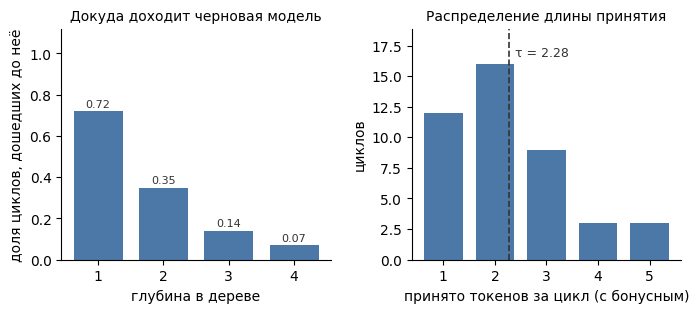

In [20]:
# --- Длина принятия по глубине и вклад ветвления ----------------------------------
max_d = max(s["accept_length"] for s in trace)
alpha = [np.mean([s["accept_length"] >= d for s in trace]) for d in range(1, max_d + 1)]

# Цепочка против дерева при одной глубине: top_k=1 — это спекулятивное
# декодирование без ветвления, вырожденный случай того же кода.
tau_tree = np.mean([s["accept_length"] + 1 for s in trace])
set_tree(total_token=6, depth=5, top_k=1)          # цепочка той же глубины
_, chain_trace = eagenerate_traced(encode(TRACE_Q), max_new_tokens=96)
tau_chain = np.mean([s["accept_length"] + 1 for s in chain_trace])
set_tree(16, 5, 3)                                  # вернуть дерево для рисунка

print(f"τ дерева  (16/5/3): {tau_tree:.2f} токенов за цикл")
print(f"τ цепочки  (6/5/1): {tau_chain:.2f} — та же черновая модель, та же глубина, без ветвления")
print(f"=> ветвление добавляет {100*(tau_tree/tau_chain - 1):.0f}% к длине принятия "
      f"при том же числе проходов целевой модели")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(8.0, 3.0),
                             gridspec_kw={"wspace": 0.30})
a1.bar(range(1, len(alpha) + 1), alpha, color=C_NAIVE, edgecolor="none", width=0.75)
for i, v in enumerate(alpha):
    a1.text(i + 1, v + 0.02, f"{v:.2f}", ha="center", fontsize=8, color=C_INK)
a1.set_xlabel("глубина в дереве"); a1.set_ylabel("доля циклов, дошедших до неё")
a1.set_title("Докуда доходит черновая модель", fontsize=10)
a1.set_ylim(0, 1.12); a1.spines[["top", "right"]].set_visible(False)

vals, cnts = np.unique([s["accept_length"] + 1 for s in trace], return_counts=True)
a2.bar(vals, cnts, color=C_NAIVE, edgecolor="none", width=0.75)
a2.axvline(tau_tree, color=C_INK, lw=1.2, ls="--")
a2.text(tau_tree + 0.12, max(cnts) * 1.04, f"τ = {tau_tree:.2f}", fontsize=9, color=C_INK)
a2.set_ylim(0, max(cnts) * 1.18)
a2.set_xlabel("принято токенов за цикл (с бонусным)"); a2.set_ylabel("циклов")
a2.set_title("Распределение длины принятия", fontsize=10)
a2.set_xticks(vals); a2.spines[["top", "right"]].set_visible(False)
finish("acceptance")


> **Вывод.** Частота принятия падает с глубиной быстро: хотя бы один черновик принимают 72% циклов, до второго уровня доходят 35%, до четвёртого — 7%, и четвёртый здесь предел. Замер в следующем разделе это подтверждает, а вывод виден уже здесь: наращивать глубину дальше нескольких уровней бессмысленно, потому что платить за неё приходится всегда, а окупается она редко.

<a id="s7"></a>
## 7. Форма дерева: два среза по одному параметру

Из [§1](#s1) следует несимметричное ожидание. **Ширина** дерева — это лишние узлы в том же самом проходе проверки, а он у нас плоский примерно до 192 токенов, то есть ширина почти бесплатна. **Глубина** — это дополнительные последовательные запуски черновой модели, каждый со своей фиксированной ценой, которую ничем не скрыть.

Чтобы это проверить, менять надо по одному параметру за раз. Сначала фиксирую `total_token` и двигаю глубину, потом фиксирую глубину и двигаю `total_token`. Каждая точка измеряется трижды, на графике — среднее и разброс: без этого выбирать конфигурацию по разнице в пару процентов бессмысленно, потому что шум карты между повторами того же порядка.

Оба среза считает ячейка ниже; она печатает для каждой точки среднее, разброс и длину принятия.

In [21]:
# --- Двухфакторная абляция с повторами ------------------------------------------
ABL_Q = [BENCH["GSM8K"][0], BENCH["MT-Bench"][0]]
ABL_TOK = 128 if QUICK else 192
REPS = 2 if QUICK else 3

def measure_tree(total_token, depth, top_k, reps=REPS, qs=None):
    qs = qs or ABL_Q
    set_tree(total_token, depth, top_k)
    with torch.no_grad():
        run_eagle(WARM, 32)
    per_rep = []
    for _ in range(reps):
        ms, taus = [], []
        for q in qs:
            r = run_eagle(encode(q), ABL_TOK)
            ms.append(ms_per_token(r)); taus.append(r["tokens"] / r["steps"])
        per_rep.append((float(np.mean(ms)), float(np.mean(taus))))
    ms_arr = np.array([p[0] for p in per_rep])
    return dict(ms=ms_arr.mean(), ms_std=ms_arr.std(),
                tau=float(np.mean([p[1] for p in per_rep])))

# базовая линия обычной генерации — тоже с повторами и тем же числом токенов
nv = []
for _ in range(REPS):
    nv.append(np.mean([ms_per_token(run_naive(encode(q), ABL_TOK)) for q in ABL_Q]))
NAIVE_MS, NAIVE_STD = float(np.mean(nv)), float(np.std(nv))
print(f"обычная генерация: {NAIVE_MS:.2f} ± {NAIVE_STD:.2f} мс/токен "
      f"(разброс {100*NAIVE_STD/NAIVE_MS:.1f}%)\n")

DEPTHS = [2, 4, 6, 8] if QUICK else [1, 2, 3, 4, 6, 8, 10]
SIZES_T = [16, 48, 96] if QUICK else [8, 16, 32, 48, 64, 96, 128]

print("A. глубина при фиксированном total_token = 64, top_k = 10")
depth_res = {}
for d in DEPTHS:
    depth_res[d] = measure_tree(64, d, 10)
    print(f"   depth={d:2d}: {depth_res[d]['ms']:5.2f} ± {depth_res[d]['ms_std']:.2f} мс/ток | "
          f"τ {depth_res[d]['tau']:4.2f} | ускорение {NAIVE_MS/depth_res[d]['ms']:4.2f}x")

# Замедление из §5 снято на глубоком дереве. Тот же срез по глубине на русскоязычном наборе
# показывает, где кривая пересекает единицу, — иначе это остаётся догадкой.
RU_Q = BENCH[LANG_SET][:2]
RU_DEPTHS = [2, 7] if QUICK else [2, 4, 7, 10]
nv_ru = []
for _ in range(REPS):
    nv_ru.append(np.mean([ms_per_token(run_naive(encode(q), ABL_TOK)) for q in RU_Q]))
NAIVE_RU = float(np.mean(nv_ru))
print(f"\nC. глубина на русскоязычном наборе (обычная генерация {NAIVE_RU:.2f} мс/ток)")
depth_ru = {}
for d in RU_DEPTHS:
    depth_ru[d] = measure_tree(64, d, 10, qs=RU_Q)
    print(f"   depth={d:2d}: {depth_ru[d]['ms']:5.2f} ± {depth_ru[d]['ms_std']:.2f} мс/ток | "
          f"τ {depth_ru[d]['tau']:4.2f} | ускорение {NAIVE_RU/depth_ru[d]['ms']:4.2f}x")

print("\nB. размер дерева при фиксированной depth = 6, top_k = 10")
size_res = {}
for s in SIZES_T:
    size_res[s] = measure_tree(s, 6, 10)
    print(f"   total_token={s:3d}: {size_res[s]['ms']:5.2f} ± {size_res[s]['ms_std']:.2f} мс/ток | "
          f"τ {size_res[s]['tau']:4.2f} | ускорение {NAIVE_MS/size_res[s]['ms']:4.2f}x")


обычная генерация: 46.08 ± 0.21 мс/токен (разброс 0.4%)

A. глубина при фиксированном total_token = 64, top_k = 10
   depth= 1: 21.04 ± 0.07 мс/ток | τ 2.51 | ускорение 2.19x
   depth= 2: 20.16 ± 0.09 мс/ток | τ 2.78 | ускорение 2.29x
   depth= 3: 20.43 ± 0.06 мс/ток | τ 2.91 | ускорение 2.26x
   depth= 4: 20.74 ± 0.06 мс/ток | τ 3.04 | ускорение 2.22x
   depth= 6: 22.15 ± 0.09 мс/ток | τ 3.09 | ускорение 2.08x
   depth= 8: 23.77 ± 0.04 мс/ток | τ 3.12 | ускорение 1.94x
   depth=10: 25.41 ± 0.05 мс/ток | τ 3.12 | ускорение 1.81x

C. глубина на русскоязычном наборе (обычная генерация 46.20 мс/ток)
   depth= 2: 39.25 ± 0.03 мс/ток | τ 1.47 | ускорение 1.18x
   depth= 4: 44.38 ± 0.26 мс/ток | τ 1.42 | ускорение 1.04x
   depth= 7: 48.18 ± 0.05 мс/ток | τ 1.50 | ускорение 0.96x
   depth=10: 55.23 ± 0.24 мс/ток | τ 1.42 | ускорение 0.84x

B. размер дерева при фиксированной depth = 6, top_k = 10
   total_token=  8: 27.06 ± 0.05 мс/ток | τ 2.46 | ускорение 1.70x
   total_token= 16: 24.80 ± 0.0

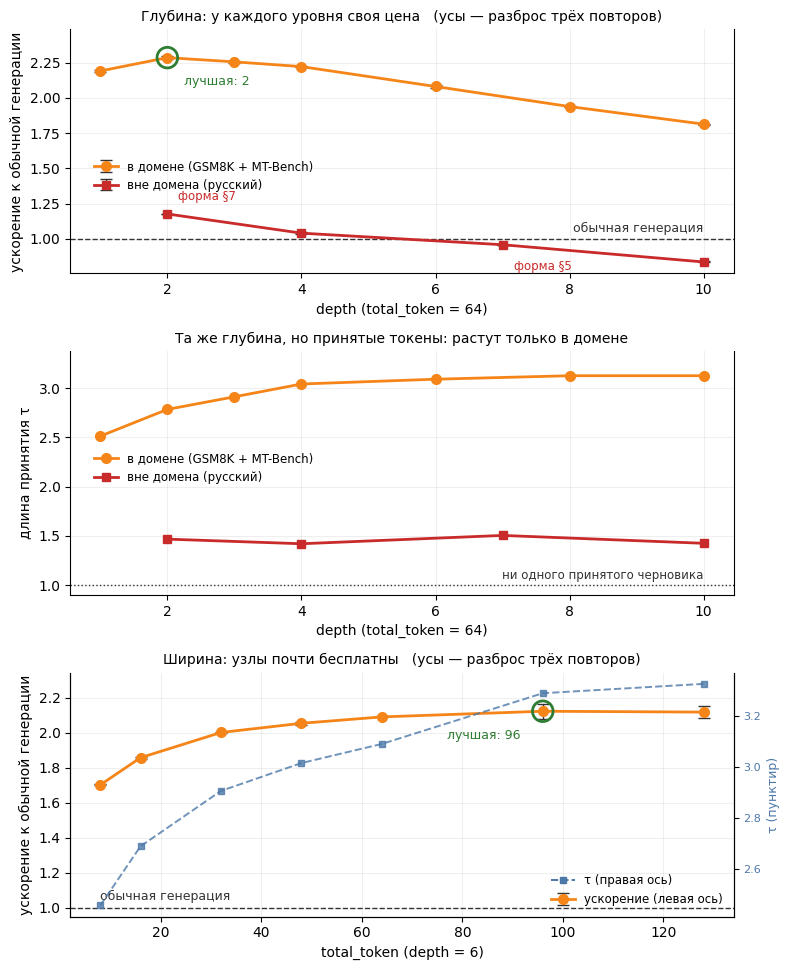

лучшая глубина (при total_token = 64): 2
лучший размер  (при depth = 6):        96
τ с ростом дерева: 2.46 -> 3.32, с ростом глубины: 2.51 -> 3.12

совмещённая точка 96/2/10: 20.76 ± 0.36 мс/ток | τ 2.81 | ускорение 2.22x
она не лучше лучших точек из отдельных срезов — параметры взаимодействуют, берём лучшую проверенную конфигурацию


In [22]:
# --- График абляции --------------------------------------------------------------
fig, (a1, a2, a3) = plt.subplots(3, 1, figsize=(8.0, 9.8))
ks    = list(depth_res.keys())
ks_ru = list(depth_ru.keys())
C_OUT = "#C92A2A"

# --- панель 1: цена глубины на обоих доменах -------------------------------------
sp     = np.array([NAIVE_MS / depth_res[k]["ms"] for k in ks])
err    = np.array([NAIVE_MS / depth_res[k]["ms"] * depth_res[k]["ms_std"] / depth_res[k]["ms"] for k in ks])
sp_ru  = np.array([NAIVE_RU / depth_ru[k]["ms"] for k in ks_ru])
err_ru = np.array([NAIVE_RU / depth_ru[k]["ms"] * depth_ru[k]["ms_std"] / depth_ru[k]["ms"] for k in ks_ru])
a1.errorbar(ks, sp, yerr=err, fmt="o-", color=C_EAGLE, lw=2, ms=7, capsize=4,
            ecolor=C_INK, elinewidth=1, label="в домене (GSM8K + MT-Bench)")
a1.errorbar(ks_ru, sp_ru, yerr=err_ru, fmt="s-", color=C_OUT, lw=2, ms=6, capsize=4,
            ecolor=C_INK, elinewidth=1, label="вне домена (русский)")
a1.axhline(1.0, color=C_INK, lw=1.0, ls="--")
a1.text(ks[-1], 1.03, "обычная генерация", fontsize=9, color=C_INK, va="bottom", ha="right")
best_k = ks[int(np.argmax(sp))]
a1.scatter([best_k], [max(sp)], s=220, facecolor="none", edgecolor=C_OK, lw=2, zorder=5)
a1.annotate(f"лучшая: {best_k}", (best_k, max(sp)), textcoords="offset points",
            xytext=(12, -20), ha="left", fontsize=9, color=C_OK)
for _d, _lbl, _dy in ((7, "форма §5", -18), (ks_ru[0], "форма §7", 10)):
    if _d in depth_ru:
        a1.annotate(_lbl, (_d, NAIVE_RU / depth_ru[_d]["ms"]), textcoords="offset points",
                    xytext=(8, _dy), fontsize=8.5, color=C_OUT)
a1.set_ylim(min(0.78, sp_ru.min() - 0.08), max(sp) + 0.20)
a1.set_ylabel("ускорение к обычной генерации")
a1.set_title("Глубина: у каждого уровня своя цена   (усы — разброс трёх повторов)", fontsize=10)
a1.legend(frameon=False, fontsize=8.5, loc="center left", bbox_to_anchor=(0.02, 0.40))

# --- панель 2: та же глубина, но длина принятия ----------------------------------
# Здесь и виден довод раздела: в домене τ растёт с глубиной, вне его — стоит на месте.
# Значит на чужом домене глубина покупает только цену, а принятых токенов не добавляет.
a2.plot(ks, [depth_res[k]["tau"] for k in ks], "o-", color=C_EAGLE, lw=2, ms=7,
        label="в домене (GSM8K + MT-Bench)")
a2.plot(ks_ru, [depth_ru[k]["tau"] for k in ks_ru], "s-", color=C_OUT, lw=2, ms=6,
        label="вне домена (русский)")
a2.axhline(1.0, color=C_INK, lw=1.0, ls=":")
a2.text(ks[-1], 1.03, "ни одного принятого черновика", fontsize=8.5, color=C_INK,
        va="bottom", ha="right")
a2.set_ylim(0.9, max(depth_res[k]["tau"] for k in ks) + 0.25)
a2.set_ylabel("длина принятия τ")
a2.set_title("Та же глубина, но принятые токены: растут только в домене", fontsize=10)
a2.legend(frameon=False, fontsize=8.5, loc="center left", bbox_to_anchor=(0.02, 0.52))

# --- панель 3: ширина ------------------------------------------------------------
ksz  = list(size_res.keys())
spz  = np.array([NAIVE_MS / size_res[k]["ms"] for k in ksz])
errz = np.array([NAIVE_MS / size_res[k]["ms"] * size_res[k]["ms_std"] / size_res[k]["ms"] for k in ksz])
a3.errorbar(ksz, spz, yerr=errz, fmt="o-", color=C_EAGLE, lw=2, ms=7, capsize=4,
            ecolor=C_INK, elinewidth=1, label="ускорение (левая ось)")
a3.axhline(1.0, color=C_INK, lw=1.0, ls="--")
a3.text(ksz[0], 1.03, "обычная генерация", fontsize=9, color=C_INK, va="bottom", ha="left")
best_z = ksz[int(np.argmax(spz))]
a3.scatter([best_z], [max(spz)], s=220, facecolor="none", edgecolor=C_OK, lw=2, zorder=5)
_rt = best_z >= ksz[len(ksz) // 2]        # у правого края подпись уводим влево, иначе срежется
a3.annotate(f"лучшая: {best_z}", (best_z, max(spz)), textcoords="offset points",
            xytext=(-16, -20) if _rt else (12, -20), ha="right" if _rt else "left",
            fontsize=9, color=C_OK)
a3.set_ylim(min(0.95, spz.min() - 0.1), max(spz) + 0.22)
a3z = a3.twinx()
a3z.plot(ksz, [size_res[k]["tau"] for k in ksz], "s--", color=C_NAIVE, lw=1.4, ms=5, alpha=0.8)
a3z.set_ylabel("τ (пунктир)", color=C_NAIVE, fontsize=9)
a3z.tick_params(axis="y", labelcolor=C_NAIVE, labelsize=8)
a3z.spines[["top"]].set_visible(False)
a3.plot([], [], "s--", color=C_NAIVE, lw=1.4, ms=5, label="τ (правая ось)")
a3.set_ylabel("ускорение к обычной генерации")
a3.set_title("Ширина: узлы почти бесплатны   (усы — разброс трёх повторов)", fontsize=10)
a3.legend(frameon=False, fontsize=8.5, loc="lower right")

for _ax, _xl in ((a1, "depth (total_token = 64)"), (a2, "depth (total_token = 64)"),
                 (a3, "total_token (depth = 6)")):
    _ax.set_xlabel(_xl)
    _ax.spines[["top"]].set_visible(False)
    _ax.grid(alpha=0.2)
finish("ablation")

BEST_DEPTH = min(depth_res, key=lambda k: depth_res[k]["ms"])
BEST_SIZE  = min(size_res,  key=lambda k: size_res[k]["ms"])
print(f"лучшая глубина (при total_token = 64): {BEST_DEPTH}")
print(f"лучший размер  (при depth = 6):        {BEST_SIZE}")
print(f"τ с ростом дерева: {size_res[SIZES_T[0]]['tau']:.2f} -> {size_res[SIZES_T[-1]]['tau']:.2f}, "
      f"с ростом глубины: {depth_res[DEPTHS[0]]['tau']:.2f} -> {depth_res[DEPTHS[-1]]['tau']:.2f}")

# Каждый срез искал оптимум при чужом значении второго параметра, поэтому
# совмещённую точку надо проверить отдельно, а не объявлять лучшей по построению.
combo = measure_tree(BEST_SIZE, BEST_DEPTH, 10)
print(f"\nсовмещённая точка {BEST_SIZE}/{BEST_DEPTH}/10: {combo['ms']:.2f} ± {combo['ms_std']:.2f} мс/ток "
      f"| τ {combo['tau']:4.2f} | ускорение {NAIVE_MS/combo['ms']:.2f}x")
best_single = min(depth_res[BEST_DEPTH]["ms"], size_res[BEST_SIZE]["ms"])
print("она " + ("лучше" if combo["ms"] < best_single else "не лучше") +
      " лучших точек из отдельных срезов — "
      + ("параметры складываются" if combo["ms"] < best_single
         else "параметры взаимодействуют, берём лучшую проверенную конфигурацию"))


> **Вывод.** Два среза ведут себя по-разному, и так, как предсказывает арифметика первого раздела. У глубины есть отчётливый оптимум, за которым она только вредит: длина принятия выходит на плато, а время растёт с каждым новым запуском черновой модели. Ширина почти бесплатна, пока проход плоский, поэтому её кривая поднимается и упирается в потолок, а не заваливается.

Красная линия на верхней панели — та же глубина, но на чужом домене, и она объясняет замедление из [§5](#s5). Средняя панель показывает, почему: длина принятия там стоит на месте, около полутора на всех глубинах, тогда как в домене она растёт с каждым уровнем. За пределами своего домена черновик угадывает одинаково редко — что при двух уровнях, что при десяти. Значит, глубина покупает там одну только цену, и на глубоком дереве цена перевешивает: верхняя кривая уходит под единицу. То есть [§5](#s5) измеряет на стартовой, глубокой форме и получает замедление, а на выбранной здесь мелкой те же запросы дают небольшой выигрыш. Домен решает, сколько метод может выиграть; глубина — сколько он может проиграть, вплоть до смены знака.

Мелкие глубины разделяет пара процентов — примерно столько же составляет дрейф между сессиями: от прогона к прогону победитель ходит между двойкой и тройкой, тогда как форма обеих кривых не меняется. Читать этот срез стоит по форме кривой, а не по тому, какая точка на ней вышла лучшей: замер показывает, во сколько обходится глубокий дефолт: около 10%. Какая из мелких глубин лучше, он не решает.

В репозитории есть режим, который подбирает размер дерева сам. Сравниваю его выбор с тем, что показали замеры выше.

In [23]:
# --- Что предлагает авторская эвристика автоподбора -----------------------------
# В EaModel.from_pretrained есть режим total_token=-1: замеряется проход целевой модели
# на длинах 40..60, время делится на эвристические веса и берётся минимум.
CANDS, WEIGHTS = [40, 48, 50, 56, 60], [1, 1.05, 1.07, 1.1, 1.13]
scores = []
with torch.no_grad():
    for n, w in zip(CANDS, WEIGHTS):
        ids = torch.randint(0, cfg.vocab_size - 200, (1, n)).cuda()
        for _ in range(3):
            plain_forward(ids)
        t = float(np.median([timed(plain_forward, ids)[1] for _ in range(7)]))
        scores.append(t / w)
auto_pick = CANDS[int(np.argmin(scores))]
print(f"авторский автоподбор выбрал бы total_token = {auto_pick}")
print(f"срез по ширине даёт пик около {BEST_SIZE}, но снят он при depth = 6 — а на глубине,")
print(f"которую выбирает этот раздел ({BEST_DEPTH}), ширина насыщается заметно раньше.")
print(f"\nВажнее другое: эвристика крутит единственную ручку, которая здесь ничего не решает.")
print(f"Она ищет total_token в диапазоне {CANDS[0]}..{CANDS[-1]} и не трогает глубину, а платит на этой")
print("карте именно глубина — каждый уровень добавляет последовательный запуск черновика.")

if combo["ms"] <= best_single:
    MAIN_TREE = dict(total_token=int(BEST_SIZE), depth=int(BEST_DEPTH), top_k=10)
elif depth_res[BEST_DEPTH]["ms"] <= size_res[BEST_SIZE]["ms"]:
    MAIN_TREE = dict(total_token=64, depth=int(BEST_DEPTH), top_k=10)
else:
    MAIN_TREE = dict(total_token=int(BEST_SIZE), depth=6, top_k=10)
set_tree(**MAIN_TREE)
print(f"\nДальше работаем с деревом {MAIN_TREE}")


авторский автоподбор выбрал бы total_token = 60
срез по ширине даёт пик около 96, но снят он при depth = 6 — а на глубине,
которую выбирает этот раздел (2), ширина насыщается заметно раньше.

Важнее другое: эвристика крутит единственную ручку, которая здесь ничего не решает.
Она ищет total_token в диапазоне 40..60 и не трогает глубину, а платит на этой
карте именно глубина — каждый уровень добавляет последовательный запуск черновика.

Дальше работаем с деревом {'total_token': 64, 'depth': 2, 'top_k': 10}


> **Вывод.** Авторская эвристика автоподбора крутит единственную ручку, которая на этой карте ничего не решает: она перебирает размер дерева в диапазоне 40–60 узлов и не трогает глубину, а платит здесь именно глубина. Собственный оптимум среза по ширине лежит выше её потолка, но снят он при depth = 6 и перехода на мелкое дерево не переживает. Эвристику настраивали на других моделях и другом железе, и это тот случай, когда чужую настройку надо перемерить у себя, а не наследовать.

<a id="s8"></a>
## 8. Куда уходит время цикла

У цикла четыре фазы: черновики (последовательные проходы головы), проверка (один проход целевой модели по всему дереву), выбор пути и всё остальное — копирование кэша, построение следующего дерева, служебная логика на стороне процессора.

Остаток получается вычитанием, но одним вычитанием я не ограничиваюсь: обёртки с синхронизацией сами стоят времени, поэтому рядом привожу время того же прогона без инструментации. Разница между двумя прогонами — цена самого измерения, и её видно.

Оборачиваю три фазы цикла таймерами и прогоняю дважды: с инструментацией и без неё. 

In [24]:
# --- Разбор цикла по фазам -------------------------------------------------------
import eagle.model.ea_model as ea_mod

PHASE_Q = encode(BENCH["MT-Bench"][0])
clean = run_eagle(PHASE_Q, N_TOK)            # эталон без инструментации

acc_t = {"черновики": 0.0, "проверка": 0.0, "выбор пути": 0.0}
def wrap(fn, key):
    def w(*a, **k):
        torch.cuda.synchronize(); t = time.perf_counter()
        r = fn(*a, **k)
        torch.cuda.synchronize(); acc_t[key] += time.perf_counter() - t
        return r
    return w

orig_topk = model.ea_layer.topK_genrate
orig_td, orig_ep = ea_mod.tree_decoding, ea_mod.evaluate_posterior
model.ea_layer.topK_genrate = wrap(orig_topk, "черновики")
ea_mod.tree_decoding = wrap(orig_td, "проверка")
ea_mod.evaluate_posterior = wrap(orig_ep, "выбор пути")
inst = run_eagle(PHASE_Q, N_TOK)
model.ea_layer.topK_genrate = orig_topk
ea_mod.tree_decoding, ea_mod.evaluate_posterior = orig_td, orig_ep

steps = inst["steps"]
parts = {k: 1000 * v / steps for k, v in acc_t.items()}
cycle_ms = 1000 * inst["sec"] / steps
parts["остальное"] = cycle_ms - sum(parts.values())
clean_cycle = 1000 * clean["sec"] / clean["steps"]

print(f"цикл (с инструментацией): {cycle_ms:.1f} мс, приносит τ = {inst['tokens']/steps:.2f}")
print(f"цикл (без инструментации): {clean_cycle:.1f} мс  <- цена самих замеров "
      f"{cycle_ms - clean_cycle:.1f} мс")
for k, v in parts.items():
    print(f"   {k:12s} {v:5.1f} мс ({100*v/cycle_ms:4.1f}%)")
print(f"\nобычный шаг: {NAIVE_MS:.1f} мс на 1 токен")
print(f"проверка дерева из {MAIN_TREE['total_token']} узлов: {parts['проверка']:.1f} мс "
      f"= {parts['проверка']/NAIVE_MS:.2f} обычного шага")
print(f"а проход целевой модели из §1 на {MAIN_TREE['total_token']} токенах: "
      f"{roof[min(SIZES, key=lambda s: abs(s-MAIN_TREE['total_token']))]:.1f} мс — сходится")


цикл (с инструментацией): 56.2 мс, приносит τ = 2.52
цикл (без инструментации): 55.8 мс  <- цена самих замеров 0.3 мс
   черновики      9.0 мс (16.0%)
   проверка      45.4 мс (80.9%)
   выбор пути     0.4 мс ( 0.7%)
   остальное      1.4 мс ( 2.4%)

обычный шаг: 46.1 мс на 1 токен
проверка дерева из 64 узлов: 45.4 мс = 0.99 обычного шага
а проход целевой модели из §1 на 64 токенах: 47.3 мс — сходится


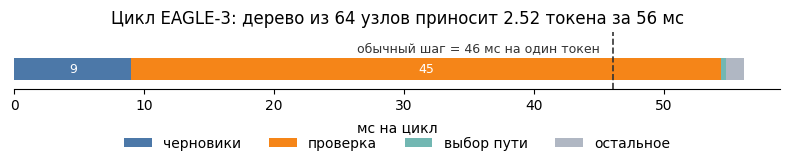

In [25]:
# --- График фаз ------------------------------------------------------------------
PH_COLORS = {"черновики": C_NAIVE, "проверка": C_EAGLE,
             "выбор пути": "#72B7B2", "остальное": "#B0B7C3"}
fig, ax = plt.subplots(figsize=(8.0, 2.7))
left = 0
for k, v in parts.items():
    ax.barh([0], [v], left=left, height=0.5, color=PH_COLORS[k], label=k)
    if v > 4:
        ax.text(left + v / 2, 0, f"{v:.0f}", ha="center", va="center", fontsize=9, color="white")
    left += v
ax.axvline(NAIVE_MS, color=C_INK, lw=1.2, ls="--")
ax.text(NAIVE_MS - 1, 0.48, f"обычный шаг = {NAIVE_MS:.0f} мс на один токен",
        fontsize=9, color=C_INK, ha="right", va="center")
ax.set_xlabel("мс на цикл", labelpad=6); ax.set_yticks([]); ax.set_ylim(-0.45, 0.85)
ax.set_title(f"Цикл EAGLE-3: дерево из {MAIN_TREE['total_token']} узлов приносит "
             f"{inst['tokens']/steps:.2f} токена за {cycle_ms:.0f} мс")
ax.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.62))
ax.spines[["top", "right", "left"]].set_visible(False)
finish("cycle_phases")


> **Вывод.** Проверка занимает около 80% цикла и стоит практически столько же, сколько обычный шаг ради одного токена. Только приносит она не один токен, а два с половиной — дерево здесь уже в той форме, которую выбрал [§7](#s7). Черновая модель забирает около 15%, выбор пути и копирование кэша вместе — пара процентов. Та же цена, больше результата.

<a id="s9"></a>
## 9. Температура: где проверяется главная гарантия метода

Вторая половина обещания — то, что метод ничего не портит.

При жадном декодировании «неухудшение качества» — почти тавтология: принимается только тот черновик, который совпал с `argmax` целевой модели. Содержательная гарантия формулируется для сэмплирования: спекулятивное декодирование обязано выдавать в точности то же распределение, что и обычное сэмплирование из целевой модели.

Здесь нужна точность, потому что реализация в репозитории отличается от того, что описано в классических статьях. У [Leviathan](https://arxiv.org/abs/2211.17192) и [Chen](https://arxiv.org/abs/2302.01318) черновик принимается с вероятностью $\min(1,\, p/q)$, где $p$ — вероятность по целевой модели, $q$ — по черновой, а при отказе сэмплируют из нормализованной разности. В коде EAGLE (`evaluate_posterior`, ветка с `logits_processor`) стоит `qx = 1.0`: кандидат принимается с вероятностью p(x), при отказе p(x) обнуляется, распределение перенормируется, и пробуется следующий уникальный кандидат из дерева.

Эта схема тоже несмещённая, и убедиться в этом можно в одну строку. Вероятность того, что кандидат $a$ будет отвергнут, а на его месте окажется токен $b$, равна

$$\bigl(1 - p(a)\bigr)\cdot\frac{p(b)}{1 - p(a)} = p(b)$$

Первый множитель — вероятность отказать кандидату, второй — вероятность выбрать $b$ из перенормированного распределения; множитель отказа сокращается с нормировкой. Индукцией по кандидатам получается то же самое для любого их числа, так что итоговое распределение совпадает с p при любой стратегии предложения: черновая модель влияет на скорость, но не на то, что получится.

Всё это доказано для точной арифметики. В fp16 логиты по дереву и логиты по одному токену считаются разными последовательностями операций, и совпадать бит-в-бит они не обязаны. Поэтому измеряю обе вещи сразу: совпадают ли распределения и насколько расходятся логиты.

Прогоняю одни и те же запросы при четырёх значениях температуры и смотрю, как меняются длина принятия и скорость.

T=0.0: τ 2.76 | 20.17 мс/ток | ускорение 2.28x
T=0.3: τ 2.89 | 21.85 мс/ток | ускорение 2.11x
T=0.7: τ 2.70 | 21.57 мс/ток | ускорение 2.14x
T=1.0: τ 2.93 | 20.36 мс/ток | ускорение 2.26x


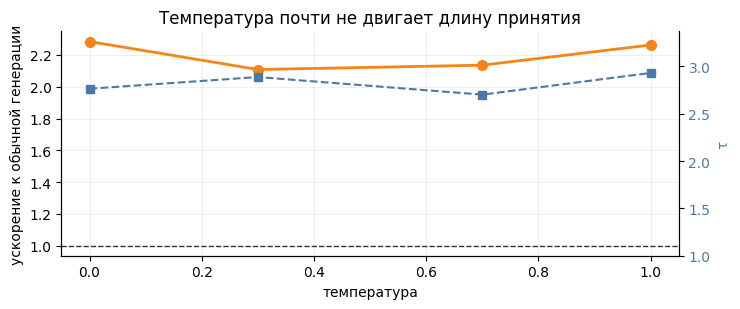

In [26]:
# --- τ и скорость в зависимости от температуры ----------------------------------
TEMPS = [0.0, 0.3, 0.7, 1.0]
T_Q = [BENCH["GSM8K"][0], BENCH["MT-Bench"][0]]
T_TOK = 96 if QUICK else 160

temp_rows = []
for T in TEMPS:
    ms, taus = [], []
    for q in T_Q:
        ids = encode(q)
        with NoEOS():
            (_, new, idx), dt = timed(model.eagenerate, ids, temperature=T,
                                      top_k=0, top_p=0.0, max_new_tokens=T_TOK, log=True)
        ms.append(1000 * dt / int(new)); taus.append(int(new) / (idx + 1))
    temp_rows.append(dict(T=T, ms=float(np.mean(ms)), tau=float(np.mean(taus)),
                          speedup=NAIVE_MS / float(np.mean(ms))))
    print(f"T={T:3.1f}: τ {temp_rows[-1]['tau']:4.2f} | "
          f"{temp_rows[-1]['ms']:5.2f} мс/ток | ускорение {temp_rows[-1]['speedup']:4.2f}x")

td = pd.DataFrame(temp_rows)
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.plot(td["T"], td["speedup"], "o-", color=C_EAGLE, lw=2, ms=7, label="ускорение")
ax.axhline(1.0, color=C_INK, lw=1.0, ls="--")
ax2 = ax.twinx()
ax2.plot(td["T"], td["tau"], "s--", color=C_NAIVE, lw=1.5, ms=6, label="τ")
ax2.set_ylabel("τ", color=C_NAIVE); ax2.tick_params(axis="y", labelcolor=C_NAIVE)
# база τ = 1 (обычная генерация): иначе автомасштаб раздувает шум в размах
ax2.set_ylim(1.0, max(td["tau"]) * 1.15)
ax.set_xlabel("температура"); ax.set_ylabel("ускорение к обычной генерации")
ax.set_title("Температура почти не двигает длину принятия")
ax.spines[["top"]].set_visible(False); ax2.spines[["top"]].set_visible(False)
ax.grid(alpha=0.2)
finish("temperature")


> **Вывод.** Ожидание было такое: чем выше температура, тем реже черновик угадывает и тем меньше выигрыш. У авторов оно подтверждается — для LLaMA-3.1-8B они приводят 4.44× при T = 0 против 3.45× при T = 1, то есть падение примерно на 20%. Мой замер такого падения не показывает: длина принятия и ускорение гуляют в пределах нескольких процентов без внятного тренда. Считать это опровержением я не стал бы — здесь два запроса без повторов, целевая модель почти впятеро меньше и генерация короче, так что чувствительности может не хватать. Что можно утверждать: обвала при полном сэмплировании не происходит, метод остаётся примерно вдвое быстрее обычной генерации.

Собираю по 500 независимых продолжений каждым способом. Диапазоны случайных зёрен у них разные: выборки должны быть независимыми, иначе сравнение окажется парным и покажет сходство там, где его нет.

In [27]:
# --- Эмпирическая проверка: совпадают ли распределения при T = 1 -----------------
import random as _random

DIST_PROMPT = "List five random English nouns, comma-separated. Words only, no explanation."
K_TOK = 5                                  # сколько первых токенов сравниваем
M = 200 if QUICK else 500                  # выборок на каждый способ
dist_ids = encode(DIST_PROMPT)

def sample_prefixes(fn, m, seed0):
    """m независимых продолжений длины K_TOK при температуре 1."""
    out = []
    for i in range(m):
        # приём/отклонение использует random.random(), выбор токена — torch: сеем оба
        torch.manual_seed(seed0 + i); _random.seed(seed0 + i)
        with NoEOS():
            res = fn(dist_ids, temperature=1.0, top_k=0, top_p=0.0,
                     max_new_tokens=K_TOK + 1, log=True)
        g = res[0][0, dist_ids.shape[1]:].tolist()
        if len(g) >= K_TOK:
            out.append(tuple(g[:K_TOK]))
    return out

t0 = time.time()
# Диапазоны сидов разные: выборки должны быть независимыми, иначе сравнение парное
ea_s  = sample_prefixes(model.eagenerate,    M,  50_000)
nv_s  = sample_prefixes(model.naivegenerate, M,  90_000)
nv2_s = sample_prefixes(model.naivegenerate, M, 300_000)   # контрольная выборка
print(f"собрано за {time.time()-t0:.0f} с: EAGLE {len(ea_s)}, обычная {len(nv_s)}, "
      f"контрольная {len(nv2_s)}")


собрано за 493 с: EAGLE 500, обычная 500, контрольная 500


Статистику здесь легко испортить.

Сравнивать эмпирические распределения по расстоянию полной вариации (TV) недостаточно: у двух конечных выборок из одного и того же распределения TV всё равно больше нуля, и тем больше, чем шире носитель. Значит, нужна нулевая полоса — сколько TV набегает просто от того, что выборки конечны.

Бутстрэп из наблюдённой выборки для этого не годится: пересэмплирование из пула даёт больше совпадений, чем два настоящих независимых замера, полоса выходит слишком узкой, и тест объявляет расхождением любую разницу. Правильный инструмент — **перестановочный тест**: если распределения совпадают, метки выборок обменимы, поэтому перемешивание меток между объединёнными выборками даёт точную нулевую статистику без предположений о носителе.

И чтобы не судить об исправности теста по тем же данным, которые он проверяет, рядом идёт контроль: две независимые выборки обычной генерации. Разницы на них тест найти не должен.

In [28]:
# --- Перестановочный тест равенства распределений --------------------------------
def tv(a, b):
    ca, cb = Counter(a), Counter(b)
    return 0.5 * sum(abs(ca[k]/len(a) - cb[k]/len(b)) for k in set(ca) | set(cb))

_rng = np.random.default_rng(0)

def perm_test(a, b, reps=1500):
    """Возвращает наблюдённое TV, 95-й процентиль нулевого, p-value и нулевую выборку."""
    obs = tv(a, b)
    pool = list(a) + list(b)
    na, idx = len(a), np.arange(len(a) + len(b))
    null = np.empty(reps)
    for r in range(reps):
        _rng.shuffle(idx)
        null[r] = tv([pool[i] for i in idx[:na]], [pool[i] for i in idx[na:]])
    return obs, float(np.percentile(null, 95)), float((null >= obs).mean()), null

print("КОНТРОЛЬ — обычная против обычной (тест обязан НЕ найти разницы):")
c_obs, c_thr, c_p, c_null = perm_test(nv_s, nv2_s)
print(f"  совместное распределение {K_TOK} токенов: TV={c_obs:.4f}, "
      f"порог={c_thr:.4f}, p={c_p:.3f}  "
      f"{'тест исправен' if c_p > 0.05 else 'ТЕСТ СЛОМАН — дальше не смотрим'}")

print("\nТЕСТ — EAGLE против обычной:")
obs, thr, pval, null = perm_test(ea_s, nv_s)
print(f"  совместное распределение {K_TOK} токенов: TV={obs:.4f}, "
      f"порог={thr:.4f}, p={pval:.3f}")
print(f"  различных последовательностей: обычная {len(set(nv_s))}, EAGLE {len(set(ea_s))}")
print(f"  ВЕРДИКТ: {'распределения неразличимы' if pval > 0.05 else 'найдено расхождение'}")

print("\nпо отдельным позициям (позиция 0 берётся из логитов целевой модели напрямую,")
print("позиции 1 и дальше уже проходят через спекулятивный приём и отклонение):")
for j in range(K_TOK):
    o, t_, p_, _ = perm_test([x[j] for x in ea_s], [x[j] for x in nv_s], reps=600)
    oc, tc, pc, _ = perm_test([x[j] for x in nv_s], [x[j] for x in nv2_s], reps=600)
    sup = len(set(x[j] for x in nv_s))
    print(f"  поз {j}: EAGLE p={p_:.3f} {'ok' if p_ > 0.05 else '!!'} | "
          f"контроль p={pc:.3f} | различных токенов {sup}")


КОНТРОЛЬ — обычная против обычной (тест обязан НЕ найти разницы):
  совместное распределение 5 токенов: TV=0.1440, порог=0.1940, p=0.865  тест исправен

ТЕСТ — EAGLE против обычной:
  совместное распределение 5 токенов: TV=0.2060, порог=0.2060, p=0.053
  различных последовательностей: обычная 65, EAGLE 65
  ВЕРДИКТ: распределения неразличимы

по отдельным позициям (позиция 0 берётся из логитов целевой модели напрямую,
позиции 1 и дальше уже проходят через спекулятивный приём и отклонение):
  поз 0: EAGLE p=0.033 !! | контроль p=0.827 | различных токенов 10
  поз 1: EAGLE p=0.528 ok | контроль p=0.410 | различных токенов 3
  поз 2: EAGLE p=0.003 !! | контроль p=0.192 | различных токенов 12
  поз 3: EAGLE p=0.498 ok | контроль p=0.482 | различных токенов 11
  поз 4: EAGLE p=0.118 ok | контроль p=0.507 | различных токенов 16


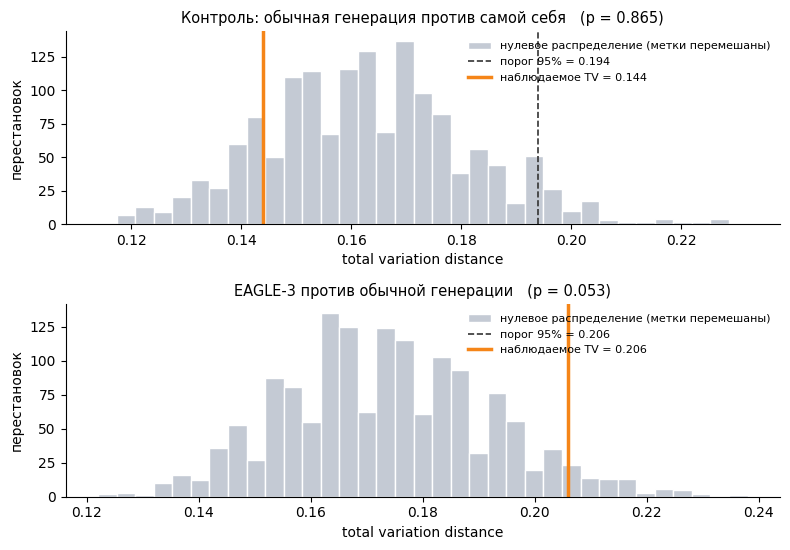

частоты первого токена (обычная | контрольная | EAGLE):
         'book':  174 |  174 |  160
        'apple':  137 |  141 |  180
          'dog':   72 |   83 |   65
          'cat':   68 |   60 |   51
          'car':   35 |   27 |   29
         'bird':    6 |    4 |    6
         'tree':    3 |    6 |    4
         'door':    3 |    2 |    1


In [29]:
# --- График: наблюдаемое TV на фоне нулевого распределения -----------------------
fig, (a1, a2) = plt.subplots(2, 1, figsize=(8.0, 5.6))
for ax, nl, o, th, p, ttl in (
        (a1, c_null, c_obs, c_thr, c_p, "Контроль: обычная генерация против самой себя"),
        (a2, null,   obs,   thr,   pval, "EAGLE-3 против обычной генерации")):
    ax.hist(nl, bins=35, color=C_GRID, edgecolor="white",
            label="нулевое распределение (метки перемешаны)")
    ax.axvline(th, color=C_INK, lw=1.2, ls="--", label=f"порог 95% = {th:.3f}")
    ax.axvline(o, color=C_EAGLE, lw=2.5, label=f"наблюдаемое TV = {o:.3f}")
    ax.set_title(f"{ttl}   (p = {p:.3f})", fontsize=10.5)
    ax.set_xlabel("total variation distance")
    ax.set_ylabel("перестановок")
    ax.legend(frameon=False, fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
finish("losslessness_t1")

print("частоты первого токена (обычная | контрольная | EAGLE):")
c1, c2, c3 = (Counter(x[0] for x in nv_s), Counter(x[0] for x in nv2_s),
              Counter(x[0] for x in ea_s))
for k, v in c1.most_common(8):
    print(f"   {tok.decode([k])!r:>12}: {v:4d} | {c2[k]:4d} | {c3[k]:4d}")


> **Вывод.** Сверху контроль: две независимые выборки обычной генерации, и тест не находит между ними разницы — значит, он не склонен видеть расхождения там, где их нет. Снизу сравнение с EAGLE, и наблюдаемое расстояние укладывается в то же нулевое распределение. Укладывается впритык: p выходит к самой границе, запаса этот тест не оставляет. Поэтому вопрос закрывает не он, а прямое сравнение распределений ниже.

### Откуда берётся остаточная разница

Совместный тест разницы не находит, но по двум позициям из пяти p оказывается низким. Прежде чем считать, что метод всё-таки сдвигает распределение, посмотрю на позицию 0: первый новый токен в обоих случаях берётся напрямую из логитов целевой модели, спекулятивный приём в нём вообще не участвует. Если разница есть уже там, значит дело в арифметике, а правило приёма ни при чём.

Здесь можно обойтись без теста: я перехватываю тензор вероятностей, из которого в каждом случае берётся первый токен, и сравниваю два распределения напрямую.

Ячейка ниже ставит хук на выбор токена и печатает обе таблицы вероятностей рядом.

In [30]:
# --- Перехват: из каких распределений берётся первый токен -----------------------
captured = {}
_tag = ["?"]
_orig_multinomial = torch.multinomial

def _capturing_multinomial(input, num_samples, *a, **kw):
    if _tag[0] not in captured:                       # только самый первый вызов
        captured[_tag[0]] = input.detach().float().cpu().clone().flatten()
    return _orig_multinomial(input, num_samples, *a, **kw)

torch.multinomial = _capturing_multinomial
try:
    # не `for name, fn in (... model.eagenerate ...)`: связанный метод переживает цикл
    # глобальной переменной и держит всю модель, из-за чего §11 не может её выгрузить
    for name, _meth in (("eagle", "eagenerate"), ("naive", "naivegenerate")):
        _tag[0] = name
        torch.manual_seed(0); _random.seed(0)
        with NoEOS():
            getattr(model, _meth)(dist_ids, temperature=1.0, top_k=0,
                                  top_p=0.0, max_new_tokens=1, log=True)
finally:
    torch.multinomial = _orig_multinomial

p_ea, p_nv = captured["eagle"], captured["naive"]
delta = (p_ea - p_nv).abs()
tv_direct = 0.5 * float(delta.sum())
print(f"размер словаря: {p_ea.numel()}")
print(f"TV между распределениями, из которых берётся первый токен: {tv_direct:.5f}")
print(f"максимальная разница вероятности одного токена: {float(delta.max()):.5f}")
print(f"бит-в-бит одинаковы: {bool(torch.equal(p_ea, p_nv))}")

top = torch.topk(p_nv, 8).indices
print("")
print(f"{'токен':>12} {'обычная':>9} {'EAGLE':>9} {'разница':>9}")
for t in top.tolist():
    print(f"{tok.decode([t])!r:>12} {float(p_nv[t]):9.5f} {float(p_ea[t]):9.5f} "
          f"{float(p_ea[t]-p_nv[t]):+9.5f}")
print("")
if tv_direct > 1e-6:
    print("Распределения различаются ещё ДО того, как включается спекулятивный приём:")
    print("первый токен в обоих случаях берётся прямо из логитов целевой модели. Значит, источник —")
    print("не правило приёма, а разный порядок операций в fp16: спекулятивный цикл")
    print("считает логиты по всему дереву разом, обычный — по одной позиции.")
    print("Тот же эффект мы уже видели при T = 0 в §10, только там он проявлялся")
    print("лишь в точках, где два кандидата почти неразличимы.")
else:
    print("Распределения совпадают бит-в-бит — остаточная разница в тесте выше")
    print("объясняется конечностью выборки и множественными сравнениями.")


размер словаря: 151936
TV между распределениями, из которых берётся первый токен: 0.00000
максимальная разница вероятности одного токена: 0.00000
бит-в-бит одинаковы: True

       токен   обычная     EAGLE   разница
     'apple'   0.33350   0.33350  +0.00000
      'book'   0.31812   0.31812  +0.00000
       'dog'   0.15259   0.15259  +0.00000
       'cat'   0.11169   0.11169  +0.00000
       'car'   0.05792   0.05792  +0.00000
      'tree'   0.01072   0.01072  +0.00000
      'bird'   0.00714   0.00714  +0.00000
      'door'   0.00302   0.00302  +0.00000

Распределения совпадают бит-в-бит — остаточная разница в тесте выше
объясняется конечностью выборки и множественными сравнениями.


<a id="s10"></a>
## 10. Совпадение с обычной генерацией при T = 0

В жадном режиме требование строже: совпадать должно не распределение, а сама последовательность. EAGLE обязан выдать ту же цепочку токенов, что и обычный цикл. Сравниваю выдачи токен за токеном. Если расхождения найдутся, измеряю их величину и смотрю, где именно они возникают.

Гипотеза для проверки простая. Обычный шаг обрабатывает один токен, спекулятивный — дерево из десятков узлов; это разные формы тензоров, разные CUDA-ядра и разный порядок суммирования в fp16. Если в какой-то позиции два лучших кандидата почти равны по логиту, порядок суммирования решает исход. Значит, в точках расхождения разрыв между top-1 и top-2 должен быть аномально мал по сравнению с обычными позициями. Это проверяемое предсказание, и его легко опровергнуть: если разрывы в точках расхождения обычные, дело не в численной погрешности, а в реализации.

Сравниваю выдачу двух способов токен за токеном на десяти запросах.

In [31]:
# --- Потокенное сравнение при T = 0 (с остановкой по EOS, как в реальной работе) --
CHECK = [(b, q) for b in BENCH for q in BENCH[b][:2]]
CHECK_TOK = 128 if QUICK else 256

diffs, checked = [], []
for bench_name, q in CHECK:
    ids = encode(q)
    (o_nv, n_nv, _), _ = timed(model.naivegenerate, ids, temperature=0.0,
                               max_new_tokens=CHECK_TOK, log=True)
    (o_ea, n_ea, _), _ = timed(model.eagenerate, ids, temperature=0.0,
                               max_new_tokens=CHECK_TOK, log=True)
    a = o_ea[0, ids.shape[1]:].tolist()
    b = o_nv[0, ids.shape[1]:].tolist()
    m = 0
    for x, y in zip(a, b):
        if x != y:
            break
        m += 1
    checked.append(dict(bench=bench_name, q=q, n=min(len(a), len(b)), match=m,
                        prefix=b[:m], ea=a, nv=b, ids=ids))
    if m < min(len(a), len(b)):
        diffs.append(checked[-1])

tot_tokens = sum(c["n"] for c in checked)
print(f"проверено {len(checked)} запросов, {tot_tokens} токенов")
print(f"полное совпадение: {len(checked)-len(diffs)} из {len(checked)} запросов")
print(f"расхождений: {len(diffs)} = {1000*len(diffs)/tot_tokens:.2f} на 1000 токенов")


проверено 10 запросов, 2219 токенов
полное совпадение: 6 из 10 запросов
расхождений: 4 = 1.80 на 1000 токенов


Теперь проверяю саму гипотезу: беру позиции, где выдачи разошлись, и смотрю на разрыв между двумя лучшими кандидатами целевой модели. Для сравнения беру тот же разрыв на позициях, где всё совпало.

запрос: MT-Bench — 'Compose an engaging travel blog post about a recent trip to '
совпало 178 токенов, дальше разошлись
  обычная: ' left me in tears of appreciation.\n\nI'
  EAGLE:   ' truly brought me into the heart of Hawaiian'

разрыв top1-top2 в точке расхождения: 0.0000
медиана разрыва на совпавших позициях:  2.8359
перцентиль точки расхождения в фоне: 0%


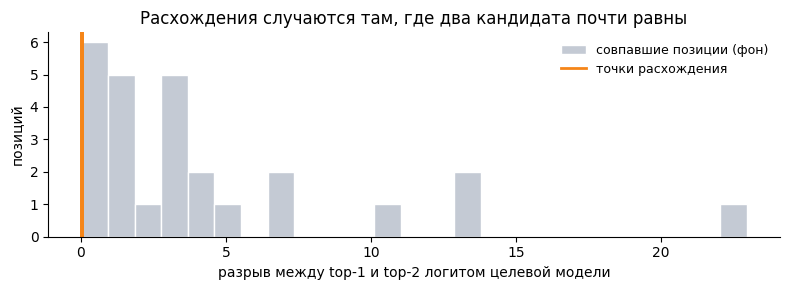


Вывод: разрывы в точках расхождения лежат у самого нуля, тогда как обычная
позиция уверенно отделена. Это ровно та картина, которую предсказывает
гипотеза о порядке суммирования в fp16, а не ошибка в правиле приёма:
гарантия losslessness формулируется для точной арифметики.


In [32]:
# --- Форензика: насколько близки логиты в точках расхождения ---------------------
@torch.no_grad()
def top2_gap(ids, prefix):
    """Разрыв между двумя лучшими логитами целевой модели после заданного префикса."""
    full = torch.cat([ids, torch.tensor([prefix], device=ids.device, dtype=torch.long)], dim=1) \
           if prefix else ids
    logits = plain_forward(full).logits[0, -1].float()
    top = torch.topk(logits, 2).values
    return float(top[0] - top[1])

if diffs:
    d = diffs[0]
    gap_at_div = top2_gap(d["ids"], d["prefix"])
    # фон: разрывы на позициях, где обе генерации совпали
    step = max(1, len(d["prefix"]) // 25)
    background = [top2_gap(d["ids"], d["prefix"][:k])
                  for k in range(1, max(2, len(d["prefix"])), step)]
    all_gaps = [top2_gap(x["ids"], x["prefix"]) for x in diffs]

    print(f"запрос: {d['bench']} — {d['q'][:60]!r}")
    print(f"совпало {d['match']} токенов, дальше разошлись")
    print(f"  обычная: {tok.decode(d['nv'][d['match']:d['match']+8])!r}")
    print(f"  EAGLE:   {tok.decode(d['ea'][d['match']:d['match']+8])!r}")
    print(f"\nразрыв top1-top2 в точке расхождения: {gap_at_div:.4f}")
    print(f"медиана разрыва на совпавших позициях:  {np.median(background):.4f}")
    print(f"перцентиль точки расхождения в фоне: "
          f"{100*np.mean([g <= gap_at_div for g in background]):.0f}%")

    fig, ax = plt.subplots(figsize=(8.0, 3.0))
    ax.hist(background, bins=25, color=C_GRID, edgecolor="white",
            label="совпавшие позиции (фон)")
    for i, g in enumerate(all_gaps):
        ax.axvline(g, color=C_EAGLE, lw=2,
                   label="точки расхождения" if i == 0 else None)
    ax.set_xlabel("разрыв между top-1 и top-2 логитом целевой модели")
    ax.set_ylabel("позиций")
    ax.set_title("Расхождения случаются там, где два кандидата почти равны")
    ax.legend(frameon=False, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    finish("divergence_gaps")
    print("\nВывод: разрывы в точках расхождения лежат у самого нуля, тогда как обычная")
    print("позиция уверенно отделена. Это ровно та картина, которую предсказывает")
    print("гипотеза о порядке суммирования в fp16, а не ошибка в правиле приёма:")
    print("гарантия losslessness формулируется для точной арифметики.")
else:
    print("расхождений не найдено — все проверенные запросы совпали токен в токен")


> **Вывод.** Гипотеза была фальсифицируемой: если расхождения вызваны численной погрешностью, они обязаны приходиться на позиции, где два кандидата почти неразличимы. Так и вышло — точки расхождения прижаты к нулю, тогда как обычная позиция отделена уверенным зазором. Это следствие порядка суммирования в fp16, а не изъян правила приёма.

<a id="scaling"></a>
## 11. Тот же метод, цель вдвое крупнее

Формула из [§1](#s1) подсказывает предсказание, которое ноутбук пока не проверял. Рассуждают обычно так: черновая голова маленькая и стоит примерно одинаково, а шаг целевой модели растёт вместе с её размером — значит, на большей цели тот же метод должен окупаться лучше. Рассуждение проверяемое, и его лучше проверить, чем повторять. Qwen3-4B — самая крупная пара, которая влезает в бесплатную T4 в fp16: 8B весит 16.4 ГБ, больше, чем есть у карты. В другую сторону сравнивать не с чем: головы под Qwen3-0.6B AngelSlim не публиковала, так что 1.7B здесь — нижняя граница измеримого.

Порядок такой. Сначала перемеряю пару 1.7B на небольшом подмножестве при той форме дерева, которую выбрал [§7](#s7), и полностью выгружаю её с карты. Потом гружу пару 4B из прикреплённых моделей и прогоняю то же подмножество, то же дерево, те же правила равной работы.

Прежде чем смотреть числа — про сам запуск. Официальный репозиторий эту голову в опубликованном виде не загружает: внимание Qwen3-4B шире её скрытого размера (32 головы внимания × 128 = 4096 против 2560), а официальный код черновика выводит ширину черновой головы из скрытого размера. Ячейка окружения правит три строки `cnets.py`, чтобы эта ширина бралась из `head_dim` в конфиге. Для пары 1.7B это ничего не меняет, и это единственная правка официального кода во всём ноутбуке.


In [33]:
# --- Замер масштабирования: пара 1.7B против пары 4B, один протокол ---------------
SCALE_SWEEP = not QUICK
SCALING = None
if SCALE_SWEEP:
    SC_Q  = BENCH["GSM8K"][:3] + BENCH["MT-Bench"][:3]
    SC_RU = BENCH[LANG_SET][:3]
    SC_TOK = 160

    def pair_numbers():
        """мс/токен обычной генерации и EAGLE плюс τ по каждому подмножеству,
        усреднённые по REPS повторам. Повторы здесь по той же причине, что и в
        абляции §7: разрывы, о которых спорит раздел, шириной в несколько процентов,
        и один проход не отделит их от дрейфа. Усы на графике — половина размаха."""
        out = {}
        for tag, qs in (("in", SC_Q), ("out", SC_RU)):
            nv_r, ea_r, tau_r = [], [], []
            for _ in range(REPS):
                nv = [ms_per_token(run_naive(encode(q), SC_TOK)) for q in qs]
                ea, taus = [], []
                for q in qs:
                    r = run_eagle(encode(q), SC_TOK)
                    ea.append(ms_per_token(r)); taus.append(r["tokens"] / r["steps"])
                nv_r.append(float(np.mean(nv))); ea_r.append(float(np.mean(ea)))
                tau_r.append(float(np.mean(taus)))
            sp_r = [a / b for a, b in zip(nv_r, ea_r)]
            half = lambda v: float((max(v) - min(v)) / 2)
            out[tag] = dict(naive_ms=float(np.mean(nv_r)), eagle_ms=float(np.mean(ea_r)),
                            tau=float(np.mean(tau_r)), speedup=float(np.mean(sp_r)),
                            tau_err=half(tau_r), speedup_err=half(sp_r), reps=REPS)
        return out

    def show_pair(name, m):
        print(f"{name} при дереве {MAIN_TREE}:")
        for tag, rus in (("in", "в домене "), ("out", "вне домена")):
            d = m[tag]
            print(f"  {rus}: обычная {d['naive_ms']:5.1f} мс/ток | EAGLE {d['eagle_ms']:5.1f} "
                  f"| τ {d['tau']:4.2f} ±{d['tau_err']:.2f} | ускорение {d['speedup']:4.2f}x "
                  f"±{d['speedup_err']:.2f} по {d['reps']} повторам")

    set_tree(**MAIN_TREE)
    with torch.no_grad():
        run_eagle(WARM, 32)
    m17 = pair_numbers()
    show_pair("пара 1.7B", m17)

    # паре 4B нужна вся карта: убираем всё, что держит пару 1.7B
    # (hf удалён ещё в §5; ea и orig_topk из §3 и §8 всё ещё держат черновую голову)
    for _n in ("model", "ea", "orig_topk", "fn"):
        globals().pop(_n, None)
    gc.collect(); torch.cuda.empty_cache()
    _left = torch.cuda.memory_allocated() / 2**30
    print(f"\nпосле выгрузки занято на GPU: {_left:.2f} ГБ")
    if _left > 1.0:                    # что-то ещё держит пару 1.7B — паре 4B не хватит места
        print("  ВНИМАНИЕ: пара 1.7B выгрузилась не полностью, паре 4B может не хватить карты")

    BASE_4B = resolve("Qwen/Qwen3-4B", "qwen-3", "4b")
    EA_4B   = resolve("AngelSlim/Qwen3-4B_eagle3", "qwen3-4b-eagle3")
    print(BASE_4B); print(EA_4B)
    t0 = time.time()
    model = EaModel.from_pretrained(
        use_eagle3=True, base_model_path=BASE_4B, ea_model_path=EA_4B,
        total_token=MAIN_TREE["total_token"], depth=MAIN_TREE["depth"],
        top_k=MAIN_TREE["top_k"], torch_dtype=torch.float16, device_map={"": 0}).eval()
    model.ea_layer.to(torch.float16)     # голова 4B выложена в bf16, у T4 его аппаратно нет;
                                         # EaModel и сам кастует голову к dtype базовой — фиксирую явно
    tok = model.get_tokenizer()
    n4 = sum(p.numel() for p in model.base_model.parameters())
    print(f"пара 4B загружена за {time.time()-t0:.0f} с | цель {n4/1e9:.2f} млрд параметров | "
          f"GPU {torch.cuda.memory_allocated()/2**30:.2f} ГБ")

    set_tree(**MAIN_TREE)
    with torch.no_grad():
        run_eagle(encode("Объясни в двух предложениях, почему небо голубое."), 32)
    m4 = pair_numbers()
    print()
    show_pair("пара 4B", m4)

    SCALING = {"tree": dict(MAIN_TREE), "n_questions": len(SC_Q), "m17": m17, "m4b": m4}
else:
    print("Режим QUICK: замер масштабирования пропущен (нужен QUICK = False)")


пара 1.7B при дереве {'total_token': 64, 'depth': 2, 'top_k': 10}:
  в домене : обычная  45.9 мс/ток | EAGLE  18.9 | τ 2.96 ±0.00 | ускорение 2.42x ±0.01 по 3 повторам
  вне домена: обычная  46.0 мс/ток | EAGLE  41.5 | τ 1.36 ±0.00 | ускорение 1.11x ±0.01 по 3 повторам

после выгрузки занято на GPU: 0.01 ГБ
/kaggle/input/models/qwen-lm/qwen-3/transformers/4b/1
/kaggle/input/models/georgymamarin/qwen3-4b-eagle3-draft-head/pytorch/bf16/1
пара 4B загружена за 71 с | цель 4.02 млрд параметров | GPU 8.65 ГБ

пара 4B при дереве {'total_token': 64, 'depth': 2, 'top_k': 10}:
  в домене : обычная  59.7 мс/ток | EAGLE  25.1 | τ 3.23 ±0.00 | ускорение 2.38x ±0.01 по 3 повторам
  вне домена: обычная  59.7 мс/ток | EAGLE  54.3 | τ 1.47 ±0.00 | ускорение 1.10x ±0.01 по 3 повторам


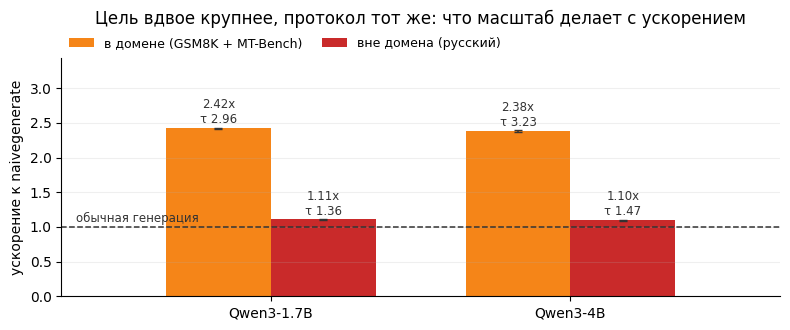

In [34]:
# --- Фигура: что масштаб делает с ускорением ---------------------------------------
if SCALE_SWEEP:
    labels = ["Qwen3-1.7B", "Qwen3-4B"]
    x = np.arange(2); w = 0.35
    fig, ax = plt.subplots(figsize=(8.0, 3.4))
    sp_in  = [SCALING["m17"]["in"]["speedup"],  SCALING["m4b"]["in"]["speedup"]]
    sp_out = [SCALING["m17"]["out"]["speedup"], SCALING["m4b"]["out"]["speedup"]]
    er_in  = [SCALING["m17"]["in"]["speedup_err"],  SCALING["m4b"]["in"]["speedup_err"]]
    er_out = [SCALING["m17"]["out"]["speedup_err"], SCALING["m4b"]["out"]["speedup_err"]]
    b1 = ax.bar(x - w/2, sp_in,  w, color=C_EAGLE, label="в домене (GSM8K + MT-Bench)",
                yerr=er_in, capsize=3, ecolor=C_INK, error_kw=dict(lw=1.1))
    b2 = ax.bar(x + w/2, sp_out, w, color="#C92A2A", label="вне домена (русский)",
                yerr=er_out, capsize=3, ecolor=C_INK, error_kw=dict(lw=1.1))
    for bars, key, errs in ((b1, "in", er_in), (b2, "out", er_out)):
        for i, b in enumerate(bars):
            m = SCALING["m17" if i == 0 else "m4b"][key]
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + errs[i] + 0.06,
                    f"{m['speedup']:.2f}x\nτ {m['tau']:.2f}", ha="center", fontsize=8.5, color=C_INK)
    ax.axhline(1.0, color=C_INK, lw=1.1, ls="--")
    ax.set_xlim(-0.7, 1.7)
    ax.text(-0.65, 1.03, "обычная генерация", fontsize=8.5, color=C_INK, va="bottom")
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylabel("ускорение к naivegenerate")
    ax.set_ylim(0, max(sp_in) * 1.42)
    ax.set_title("Цель вдвое крупнее, протокол тот же: что масштаб делает с ускорением", pad=24)
    # легенда одной строкой НАД осями: в углу её вторая строка ложилась на подпись столбика
    ax.legend(frameon=False, fontsize=9, ncol=2, loc="lower left",
              bbox_to_anchor=(0.0, 1.0), borderaxespad=0.2, columnspacing=1.6)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.2)
    finish("scaling")


> **Вывод.** Две цели, один протокол — и предсказание сбывается ровно наполовину. Длина принятия растёт вместе с размером цели, и растёт заметно: около 9% в пользу пары 4B, и в домене, и вне его. Жадное декодирование фиксирует последовательность токенов, поэтому внутри прогона все повторы возвращают одну и ту же длину принятия до третьего знака; усы на графике — чистый разброс времени. А ускорение за ней не идёт: разница между парами не выходит за 2–3%, и её знак меняется от прогона к прогону. Величина без шума говорит, что голова стала угадывать лучше; величина с шумом не может сказать, изменилось ли вообще что-нибудь. Удвоение цели купило длину принятия и, насколько эта карта способна различить, не купило скорости.

Механизм читается по сырым замерам времени; ускорения его прячут. И здесь важно не путать цикл с токеном. Обычный шаг на большей цели дорожает. Полный спекулятивный цикл — один заход черновика плюс одна проверка дерева — дорожает быстрее: проверка тащит те же расширившиеся веса, что и обычный шаг, а черновик перестал быть бесплатным. Те 9% лишних токенов, которые приносит цикл, эту разницу почти целиком и съедают. Остаётся пара процентов — того же размера, что и дрейф между прогонами, отчего её знак и гуляет.

Ломается, стало быть, предпосылка: цена черновой головы не фиксирована. Эта голова выросла вместе с целью, со 137 до 218 млн параметров, потому что её скрытый размер и внимание расширяются следом за моделью. Как доля цели она действительно ужалась, с 8.0% до 5.4%, но знаменатель формулы платит не за долю, а за абсолютное время черновика.

Столбики вне домена указывают ещё на один открытый вопрос, но не закрывают его. Ни одна пара здесь не проваливается ниже 1.0 — при том что в [§5](#s5) на тех же русскоязычных запросах метод проигрывал обычной генерации. Сказать этот замер может одно: длина принятия против [§5](#s5) почти не сдвинулась, то есть более короткое подмножество не стало легче, и поменялась цена цикла; частота, с которой черновик угадывает, осталась прежней. Указывает это на глубину дерева, и [§7](#s7) догадку проверяет: там тот же срез по глубине снят на русскоязычном наборе, и кривая пересекает единицу, пока длина принятия держится около полутора на всех глубинах.

In [35]:
import json as _json

try:
    _keys = {
        "overall": {"tau": float(overall_tau),
                    "speedup_naive": float(overall_sp),
                    "speedup_hf": float(bench_df.speedup_hf.mean())},
        "english": {"tau": float(eng.tau.mean()), "speedup": float(eng.speedup_naive.mean())},
        "russian": {"tau": float(rus.tau.mean()), "speedup": float(rus.speedup_naive.mean())},
        "by_set": {b: {"tau": float(g.tau.mean()), "speedup": float(g.speedup_naive.mean())}
                   for b, g in bench_df.groupby("bench")},
        "branching": {"tau_tree": float(tau_tree), "tau_chain": float(tau_chain),
                      "gain_pct": float(100 * (tau_tree / tau_chain - 1))},
        "cycle_ms": dict({k: float(v) for k, v in parts.items()},
                         naive_step=float(NAIVE_MS), total=float(cycle_ms)),
        "temperature": {str(r["T"]): {"tau": float(r["tau"]), "speedup": float(r["speedup"])}
                        for r in temp_rows},
        "tree": dict(MAIN_TREE),
        "scaling": globals().get("SCALING"),
        # §6 называет эти доли словами; без них проверить их нечем
        # величины, на которые ссылается проза, но которых до сих пор не было в дампе
        "roofline": {"free_upto": int(free_upto), "step_ms": float(step_ms),
                     "predicted_ms": float(predicted_ms), "mbu": float(mbu)},
        "break_even": float(tau_break),
        "cycle_tau": float(inst["tokens"] / inst["steps"]),
        "divergence": {"n_diffs": len(diffs),
                       "background_median": float(np.median(background))},
        "acceptance": {"alpha": [float(a) for a in alpha],
                       "max_accept_length": int(max(s["accept_length"] for s in trace)),
                       "n_cycles": len(trace)},
        # срезы §7: на них ссылается проза §5, §7 и §11, а argmin к тому же плавает
        "ablation": {"naive_ms": float(NAIVE_MS), "naive_ms_ru": float(NAIVE_RU),
                     "depth": {str(kk): {"ms": float(v["ms"]), "tau": float(v["tau"])}
                               for kk, v in depth_res.items()},
                     "depth_ru": {str(kk): {"ms": float(v["ms"]), "tau": float(v["tau"])}
                                  for kk, v in depth_ru.items()},
                     "size": {str(kk): {"ms": float(v["ms"]), "tau": float(v["tau"])}
                              for kk, v in size_res.items()}},
    }
    with open("/kaggle/working/key_numbers.json", "w") as _f:
        _json.dump(_keys, _f, ensure_ascii=False, indent=1)
except Exception as _e:                      # сверка не должна ронять прогон
    print("!! сводка чисел НЕ СОБРАЛАСЬ, текст сверить нечем:", repr(_e))
else:
    print(f"key_numbers.json записан ({len(_keys)} групп, scaling: "
          f"{'есть' if _keys.get('scaling') else 'нет'})")


key_numbers.json записан (15 групп, scaling: есть)


<a id="dead-ends"></a>
## 12. Что не сработало

Тупики и грабли, на которые ушло время. Перечисляю, чтобы их не повторяли.

**P100 вместо T4.** Kaggle по умолчанию выдаёт под `enable_gpu` карту P100, а предустановленный там `torch 2.10+cu128` не поддерживает `sm_60`: падает с `CUDA error: no kernel image is available`. Лечится выбором T4 (в API — поле `machine_shape: NvidiaTeslaT4`).

**Установка репозитория через pip.** `setup.py` в EAGLE тянет `torch==2.0.1` и `transformers==4.46.2` — на свежем окружении это ломает всё. Правильный путь: клонировать и добавить в `sys.path`, а версию `transformers` фиксировать отдельно (`4.53.1`; предустановленная на Kaggle 5.x несовместима с модифицированными modeling-файлами репозитория).

**Глубокое дерево по умолчанию.** Стартовая форма `60/7/10` и авторские `32/8/4` роднит одно: глубина в семь-восемь уровней. Абляция [§7](#s7) показывает, что на этой карте она не окупается — длина принятия выходит на плато уже к четвёртому уровню, а платить приходится за каждый. Сам я `32/8/4` не измерял: срез по глубине в [§7](#s7) измеряет глубину при фиксированных `total_token` и `top_k`, то есть трогает только одну из трёх ручек. Поэтому чисел именно для этой формы я не привожу — вывод здесь про глубину, и конкретная конфигурация его не меняет.

**Погоня за разницей в проценты.** Первая версия этого ноутбука выбирала конфигурацию по разнице 2.42× против 2.43× при одном прогоне на точку. Повторные замеры показали разброс порядка процента: разница была шумом. Отсюда повторы (по три на точку) и усы на всех графиках.

**Наращивание дерева до бесконечности.** τ продолжает расти и после 96 узлов, а скорость — нет: выигрыш съедается стоимостью построения самого дерева. Узкое место переезжает с проверки на черновую модель.

**Нулевая полоса из бутстрэпа.** Первая версия теста при T = 1 строила нулевую полосу пересэмплированием из наблюдённой выборки. При разреженном носителе это систематически занижает полосу: бутстрэп берёт из пула в несколько сотен значений и даёт больше совпадений, чем два настоящих независимых замера. Тест уверенно объявил расхождение там, где его нет. Перестановочный тест этим не страдает, а контроль на двух выборках обычной генерации ловит такую ошибку сразу: на сломанном тесте он тоже показывал расхождение.

**Погоня за низкими p-value по отдельным позициям.** Даже с корректным тестом две позиции из пяти дали p < 0.05. Объявить это сдвигом распределения заманчиво, но при десяти сравнениях (пять позиций на два теста) и α = 0.05 в среднем ожидается одно ложное срабатывание на два таких прогона, так что одни p-value вопрос не закрывают. Для позиции 0 его закрыл прямой замер: распределения совпадают бит-в-бит, и расхождению там взяться неоткуда. Для остальных позиций прямое сравнение невозможно в принципе — там распределение зависит от уже выпавшего префикса, а он у двух прогонов свой. Остаётся списать эти p-value на множественные сравнения: доказать сверх этого нечем.

**Тест распределения на «удобном» запросе.** Первая попытка проверить неизменность распределения при T = 1 использовала запрос, у которого продолжение почти детерминировано: TV вышло ровно 0 при нулевой полосе [0, 0]. Формально совпало, содержательно — тест ничего не проверял. Нужен запрос с реальной энтропией, иначе проверяется пустота.


<a id="takeaways"></a>
## 13. Выводы

1. **Спекулятивное декодирование работает потому, что декодирование memory-bound.** На T4 проход целевой модели не дорожает до 192 токенов, поэтому проверка целого дерева стоит примерно как генерация одного токена. Всё остальное в методе — попытки набрать побольше принятых токенов за этот один проход.
2. **Ускорение определяется длиной принятия, а её задают домен и форма дерева вместе.** Одна и та же черновая модель даёт разброс от двух с половиной раз на математике и коде до замедления на русскоязычных запросах — но замедление снято на глубоком стартовом дереве. На форме, которую выбирает [§7](#s7), те же запросы дают небольшой выигрыш при почти неизменной длине принятия, и [§11](#scaling) подтверждает это на второй паре моделей. Домен задаёт, сколько метод может выиграть; глубина дерева — сколько он может проиграть. Длину принятия надо измерять на своём распределении запросов; чужие цифры не переносятся.
3. **Ширина дерева дешевле глубины.** Ширина добавляет узлы в тот же проход проверки, глубина — новые последовательные запуски черновой модели. Авторская эвристика автоподбора при этом крутит только число узлов и вовсе не трогает глубину.
4. **Метод не портит качество, и это проверяемо тремя способами.** При T = 0 выдача совпадает потокенно, а редкие расхождения приходятся строго на позиции, где два кандидата почти неразличимы по логиту: разрыв там неотличим от нуля против типичных 2.8 логита. При T = 1 перестановочный тест не отвергает равенство распределений; контроль на двух выборках обычной генерации показывает, что тест не видит расхождения там, где его заведомо нет — на предыдущей, сломанной версии теста этот же контроль расхождение показывал. Третий способ — прямое сравнение: распределение, из которого в обоих случаях берётся первый токен, совпадает бит-в-бит. На последующих позициях так сравнить нельзя: там распределение зависит от уже выпавшего префикса.
5. **Масштаб покупает длину принятия, а не скорость — по крайней мере на этом удвоении.** Интуицию «на большей цели черновая голова окупается лучше» [§11](#scaling) доводит до замера на Qwen3-4B: τ растёт примерно на 9%, а ускорение не выходит за пределы шума, потому что цена этой головы не фиксирована: она растёт вместе со своей целью. Возобновится ли рост на 8B и дальше, этот замер не скажет: такая пара в бесплатную T4 не помещается.
6. **Заявленные ускорения всегда надо читать вместе с базовым вариантом.** Обычный шаг здесь работает на четверти пропускной способности памяти; часть измеренного выигрыша — амортизация этих накладных расходов, а не победа над памятью. На оптимизированном стеке тот же метод даёт меньше — поэтому независимые замеры на vLLM и скромнее авторских.

**Чего здесь нет.** Батч больше единицы (реализация в репозитории работает только с batch = 1, а именно батчинг сильнее всего съедает выигрыш спекуляции), длинные контексты и обучение своей головы под домен. Последнее — самое интересное продолжение, учитывая пункт 2.


<a id="use-it"></a>
## 14. Прогнать у себя, что читать дальше, лицензии

Форкните ноутбук и поменяйте две строки из четырёх, описанных в [§0](#s0):

```python
BASE_MODEL = "Qwen/Qwen3-4B"                 # любая целевая модель, под которую есть голова
EA_MODEL   = "AngelSlim/Qwen3-4B_eagle3"     # список голов — в README репозитория EAGLE
```

Про размер — как раз к примеру выше. [§5](#s5) держит на карте вторую, независимую копию цели: без неё нечем замерить штатный `generate`. Рядом с парой 1.7B она помещается свободно, рядом с парой уровня 4B — уже нет: [§11](#scaling) потому и выгружает первую пару перед загрузкой второй. Так что двухстрочный форк проверен примерно до 2B; для цели покрупнее либо уберите базовую линию штатного `generate` в [§5](#s5), либо выгружайте предыдущую пару перед загрузкой следующей, как это делает [§11](#scaling).

Чтобы измерить длину принятия на своих запросах (пункт 2 выводов), добавьте свой набор в словарь `BENCH` в [§5](#s5) — дальше все таблицы и графики построятся по нему. Где именно проходит точка окупаемости, зависит от дерева, поэтому переносить надо не число, а связку. Одна и та же длина принятия — около полутора токенов за цикл — на глубоком стартовом дереве стоит ровно на окупаемости ([§5](#s5)), а на мелком, которое выбирает [§7](#s7), уходит в небольшой плюс ([§11](#scaling)). Низкая длина принятия и глубокое дерево вместе превращают спекуляцию в проигрыш, и знать это надо до внедрения, а не после.

Ячейка ниже печатает текущую конфигурацию и то, что в ней можно менять.

In [36]:
# Текущая конфигурация разбора. Меняется в первой ячейке ноутбука.
print(f'BASE_MODEL = "{BASE_MODEL}"' + ('' if BASE_PATH == BASE_MODEL else f'   <- взято с диска: {BASE_PATH}'))
print(f'EA_MODEL   = "{EA_MODEL}"' + ('' if EA_PATH == EA_MODEL else f'   <- взято с диска: {EA_PATH}'))
print(f'дерево     = {MAIN_TREE}')
print(f'наборы     = {list(BENCH)}')
print()
print("Чтобы прогнать на своей модели: заменить две первые строки и Run All.")
print("Чтобы прогнать на своих задачах: добавить свой список в BENCH (§5).")


BASE_MODEL = "Qwen/Qwen3-1.7B"   <- взято с диска: /kaggle/input/models/qwen-lm/qwen-3/transformers/1.7b/1
EA_MODEL   = "AngelSlim/Qwen3-1.7B_eagle3"   <- взято с диска: /kaggle/input/models/georgymamarin/qwen3-1-7b-eagle3-draft-head/pytorch/fp16/1
дерево     = {'total_token': 64, 'depth': 2, 'top_k': 10}
наборы     = ['MT-Bench', 'GSM8K', 'HumanEval', 'Alpaca', 'Русский']

Чтобы прогнать на своей модели: заменить две первые строки и Run All.
Чтобы прогнать на своих задачах: добавить свой список в BENCH (§5).


### Что читать дальше

**Как метод дошёл до нынешнего вида**

- [Leviathan et al., 2211.17192](https://arxiv.org/abs/2211.17192) — исходная идея и доказательство несмещённости через rejection sampling. В приложении A.1 лежит доказательство, если хочется проверить самому.
- [Chen et al., 2302.01318](https://arxiv.org/abs/2302.01318) — независимая параллельная работа, полезна другим взглядом на то же доказательство.
- [EAGLE-1, 2401.15077](https://arxiv.org/abs/2401.15077) — почему предсказывать признак легче, чем токен.
- [EAGLE-2, 2406.16858](https://arxiv.org/abs/2406.16858) — динамическое дерево; отсюда и берутся `total_token`, `depth`, `top_k` из [§7](#s7).
- [EAGLE-3, 2503.01840](https://arxiv.org/abs/2503.01840) — разбираемая статья: отказ от `l_fea`, слияние трёх уровней, training-time test.
- [HASS, 2408.15766](https://arxiv.org/abs/2408.15766) — ближайший предок идеи раскатывать черновую модель на собственных выходах при обучении.

**На чём держится этот разбор**

- [LLM Scaling Week](https://llmscaling.yandex.com/) — лекция 1 «Deep Learning Arithmetic» (Михаил Хрущёв) даёт ту самую арифметику байтов и FLOP, на которой стоит [§1](#s1), а лекция 5 «Inference Challenges» (Роман Горб) — картину узких мест инференса целиком.
- [Курс NLP Школы анализа данных](https://github.com/yandexdataschool/nlp_course/tree/2025) — week03 про KV-кэш (фундамент [§2](#s2)) и week05 про большие языковые модели.

**Как это выглядит в промышленной эксплуатации**

- [«Performance or Illusion?», 2601.11580](https://arxiv.org/abs/2601.11580) — независимая репликация на vLLM. Главная мысль: ускорение падает с ростом батча, потому что батчинг сам по себе загружает вычислители, и на спекуляцию их уже не остаётся.

**Код и веса**

- [SafeAILab/EAGLE](https://github.com/SafeAILab/EAGLE) — официальная реализация, коммит `cb7e0841`, лицензия Apache 2.0. Ноутбук использует её как есть, за единственным исключением: три строки `cnets.py`, которые правит ячейка окружения в [§0](#s0) — без них [§11](#scaling) не загрузит голову Qwen3-4B. Смотреть надо `eagle/model/cnets.py` (построение дерева) и `eagle/model/utils.py` (проверка и работа с KV).
- [AngelSlim/Qwen3-1.7B_eagle3](https://huggingface.co/AngelSlim/Qwen3-1.7B_eagle3) — черновая голова, обученная командой [AngelSlim](https://github.com/Tencent/AngelSlim) (Tencent). Она не авторская: замеры самой команды дают длину принятия 1.8–3.5, что сходится с моей; ускорение 1.4–1.9× они приводят к своей базовой линии.
  Та же команда обучила и [AngelSlim/Qwen3-4B_eagle3](https://huggingface.co/AngelSlim/Qwen3-4B_eagle3) — голову, на которой считает [§11](#scaling).
- [Qwen/Qwen3-1.7B](https://huggingface.co/Qwen/Qwen3-1.7B) — целевая модель, лицензия Apache 2.0; в [§11](#scaling) к ней добавляется [Qwen/Qwen3-4B](https://huggingface.co/Qwen/Qwen3-4B) под той же лицензией.
- Наборы вопросов (MT-Bench, GSM8K, HumanEval, Alpaca) взяты из каталога `eagle/data` того же репозитория — это те же наборы, на которых считает статью.

---

### English summary

EAGLE-3 speculative decoding, reproduced on Qwen3-1.7B with a free Kaggle T4. The draft head is
`AngelSlim/Qwen3-1.7B_eagle3` (the authors ship no head for this target); the code is the official
`SafeAILab/EAGLE` at commit `cb7e0841`.

Everything is measured, not quoted. A target forward pass stays flat from 1 to ~192 tokens, so
verifying a whole draft tree costs about as much as generating one token — that is the entire
mechanism. Measured against the repository's own vanilla loop: 2.3× on the English benchmarks the
paper uses (MT-Bench, GSM8K, HumanEval, Alpaca) with acceptance length τ ≈ 3.4, and ≈0.95× — an actual
slowdown — on Russian prompts, where the community-trained head is out of its domain. That slowdown needs the deep starting tree, though: at the shallow shape [§7](#s7) picks, the same prompts come out slightly ahead. Branching adds
39% to τ over a plain chain of the same depth. Depth beyond 2–3 costs more than it returns: τ plateaus
at 3.1 while time keeps growing. Output is unchanged: token-identical under greedy decoding except at
positions where the top-2 logit gap is numerically zero, and a permutation test finds no distribution
shift at T = 1.

*Read this walkthrough in English: [English version](https://www.kaggle.com/code/georgymamarin/anatomy-of-a-speedup-eagle-3-on-qwen3) — the same measurements, written for a wider audience.*

---

### Авторство и благодарности

Автор разбора — [Georgy Mamarin](https://www.kaggle.com/georgymamarin). Постановка вопросов, замеры, код ноутбука и текст мои; метод, реализация, веса черновой головы и наборы вопросов принадлежат авторам, перечисленным выше.

Отдельная благодарность команде [SafeAILab](https://github.com/SafeAILab/EAGLE) — за открытую реализацию, которую разбор запускает как есть, если не считать трёх строк, без которых [§11](#scaling) не загрузит голову Qwen3-4B; команде [AngelSlim](https://huggingface.co/AngelSlim/Qwen3-1.7B_eagle3) в Tencent — за публичные черновые головы под Qwen3-1.7B и Qwen3-4B; Kaggle — за бесплатную T4, на которой всё посчитано.

Код ноутбука — Apache 2.0, модели и веса остаются под своими лицензиями.

Если воспроизведёте на другой модели или найдёте ошибку в замере, напишите в комментариях: обе новости одинаково полезны.
